In [ ]:
!pip install pandas-ta

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 120.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 133.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 148.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 17.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: pandas
    Found existing i

In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"baohuynguyen","key":"e8513f6632de13e6b93f4a35c136deaa"}'}

In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle competitions download -c aio-2025-linear-forecasting-challenge

  0% 0.00/16.8k [00:00<?, ?B/s]
100% 16.8k/16.8k [00:00<00:00, 77.6MB/s]


In [ ]:
!unzip /content/aio-2025-linear-forecasting-challenge.zip

Archive:  /content/aio-2025-linear-forecasting-challenge.zip
  inflating: FPT_train.csv           
  inflating: sample_submission.csv   


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [ ]:
sample_sub = pd.read_csv('/content/sample_submission.csv')
display(sample_sub)

,id,close
0,1,x_1
1,2,x_2
2,3,x_3
3,4,x_4
4,5,x_5
...,...,...
95,96,x_96
96,97,x_97
97,98,x_98
98,99,x_99


In [ ]:
df_train = pd.read_csv('/content/FPT_train.csv')
display(df_train)

,time,open,high,low,close,volume,symbol
0,2020-08-03,19.07,19.63,19.03,19.63,1392200,FPT
1,2020-08-04,19.89,20.01,19.76,19.91,1051310,FPT
2,2020-08-05,19.89,20.16,19.78,20.10,1328520,FPT
3,2020-08-06,20.10,20.21,19.97,20.01,1153660,FPT
4,2020-08-07,20.01,20.44,20.01,20.14,1283690,FPT
...,...,...,...,...,...,...,...
1144,2025-03-04,120.28,121.23,120.11,120.71,3480042,FPT
1145,2025-03-05,120.71,120.80,119.93,119.93,2862185,FPT
1146,2025-03-06,120.28,123.73,120.28,122.09,6428376,FPT
1147,2025-03-07,122.18,123.04,121.66,121.92,2966941,FPT


In [ ]:
df_train.drop('symbol', axis=1, inplace=True)

In [ ]:
df_train['time'] = pd.to_datetime(df_train['time'])
df_train = df_train.sort_values('time').reset_index(drop=True) if 'time' in df_train.columns else df_train

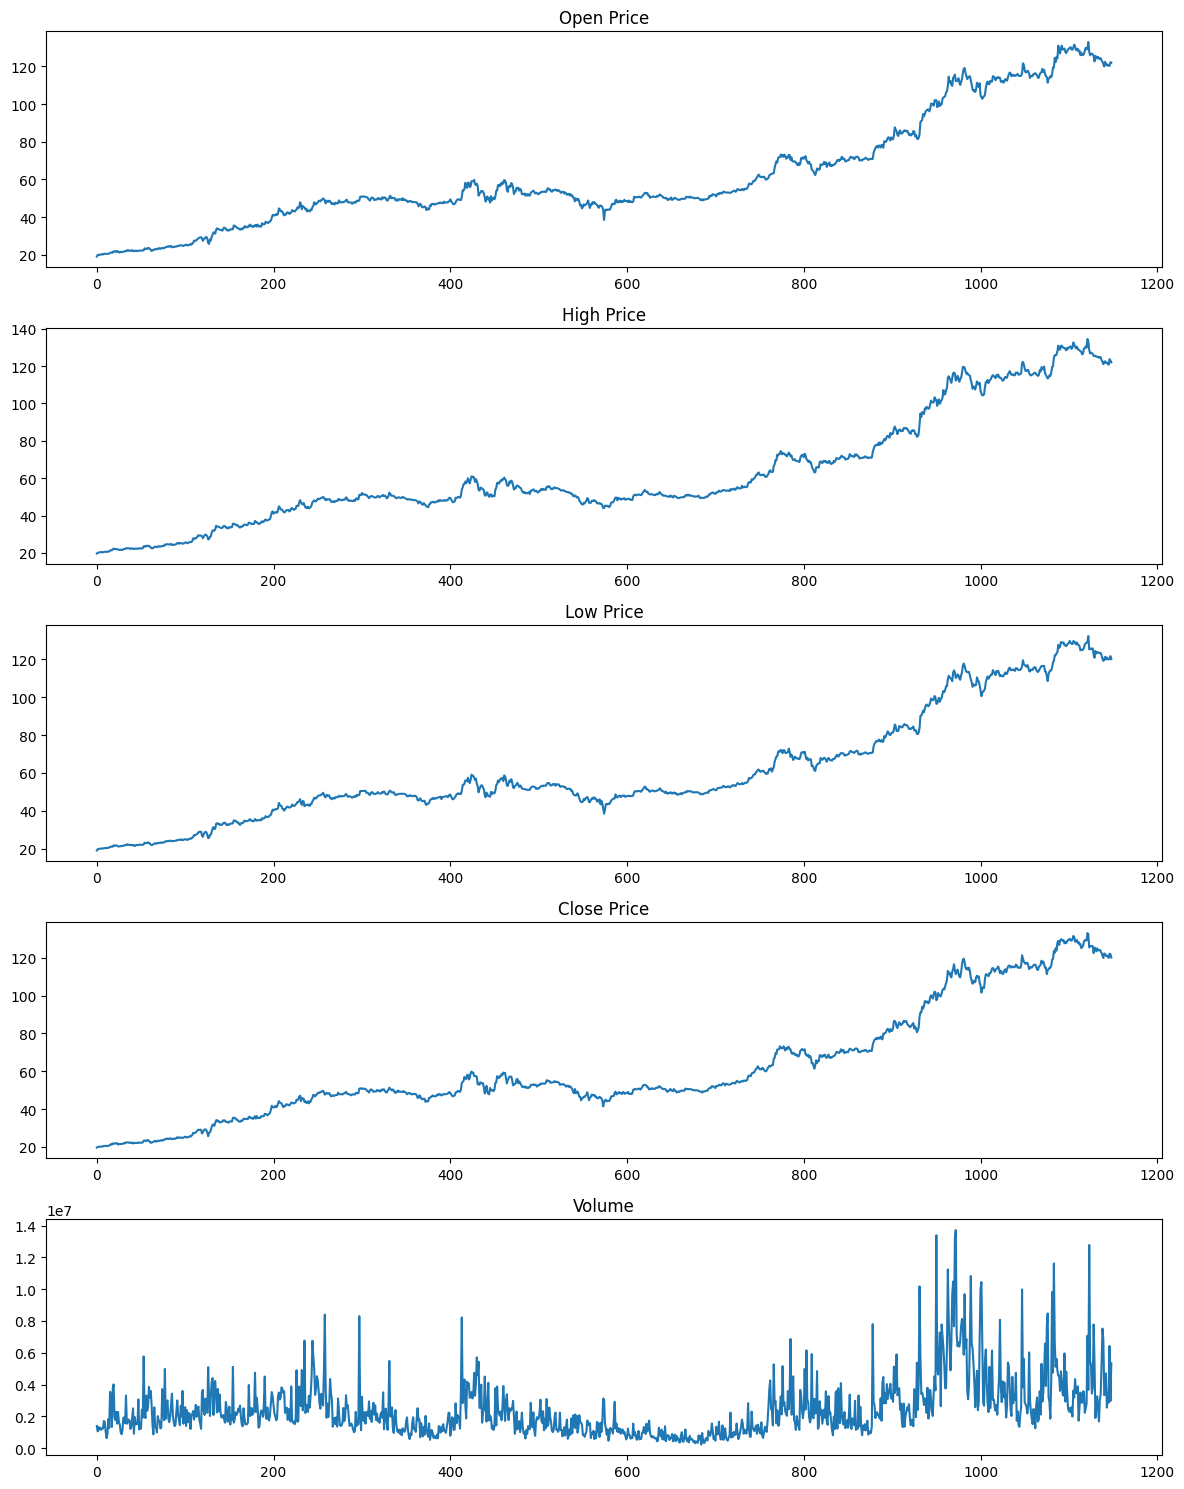

In [ ]:
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 15))

df_train['open'].plot(ax=axes[0], title='Open Price')
df_train['high'].plot(ax=axes[1], title='High Price')
df_train['low'].plot(ax=axes[2], title='Low Price')
df_train['close'].plot(ax=axes[3], title='Close Price')
df_train['volume'].plot(ax=axes[4], title='Volume')

plt.tight_layout()
plt.show()

In [ ]:
analize = df_train.copy()

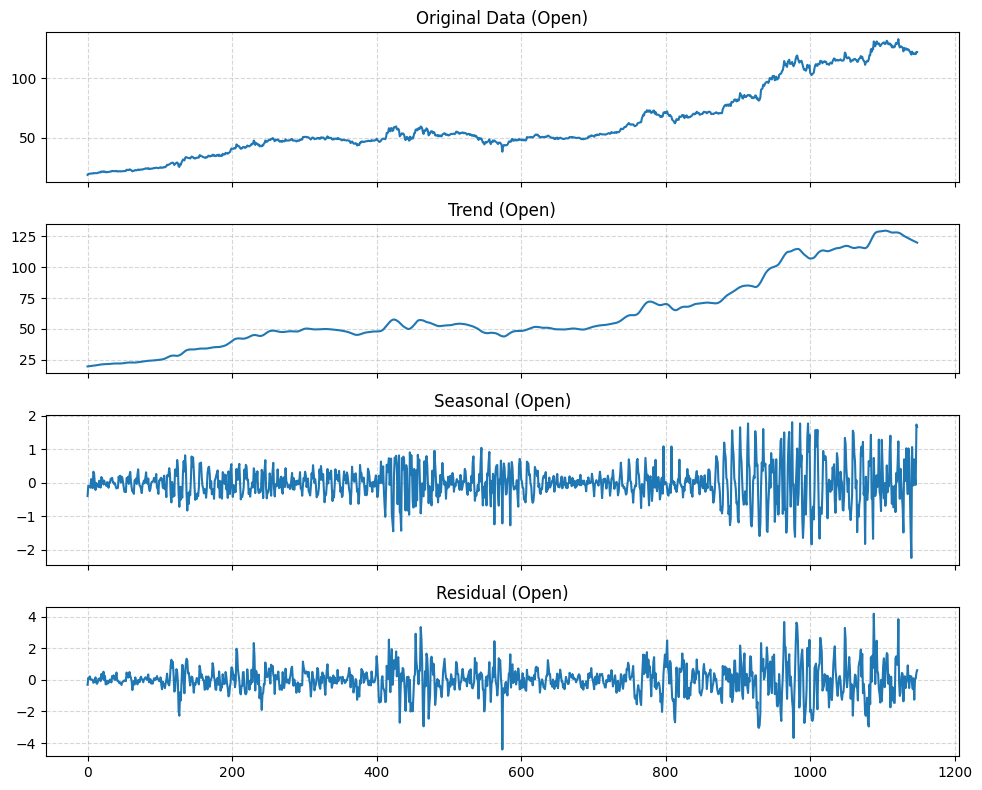

In [ ]:
from statsmodels.tsa.seasonal import STL

stl_open = STL(analize['open'], period=11)
res_open = stl_open.fit()

fig_open, axes_open = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

analize['open'].plot(ax=axes_open[0])
axes_open[0].grid(True, linestyle='--', alpha=0.5)
axes_open[0].set_title('Original Data (Open)')

res_open.trend.plot(ax=axes_open[1])
axes_open[1].grid(True, linestyle='--', alpha=0.5)
axes_open[1].set_title('Trend (Open)')

res_open.seasonal.plot(ax=axes_open[2])
axes_open[2].grid(True, linestyle='--', alpha=0.5)
axes_open[2].set_title('Seasonal (Open)')

res_open.resid.plot(ax=axes_open[3])
axes_open[3].grid(True, linestyle='--', alpha=0.5)
axes_open[3].set_title('Residual (Open)')

plt.tight_layout()
plt.show()

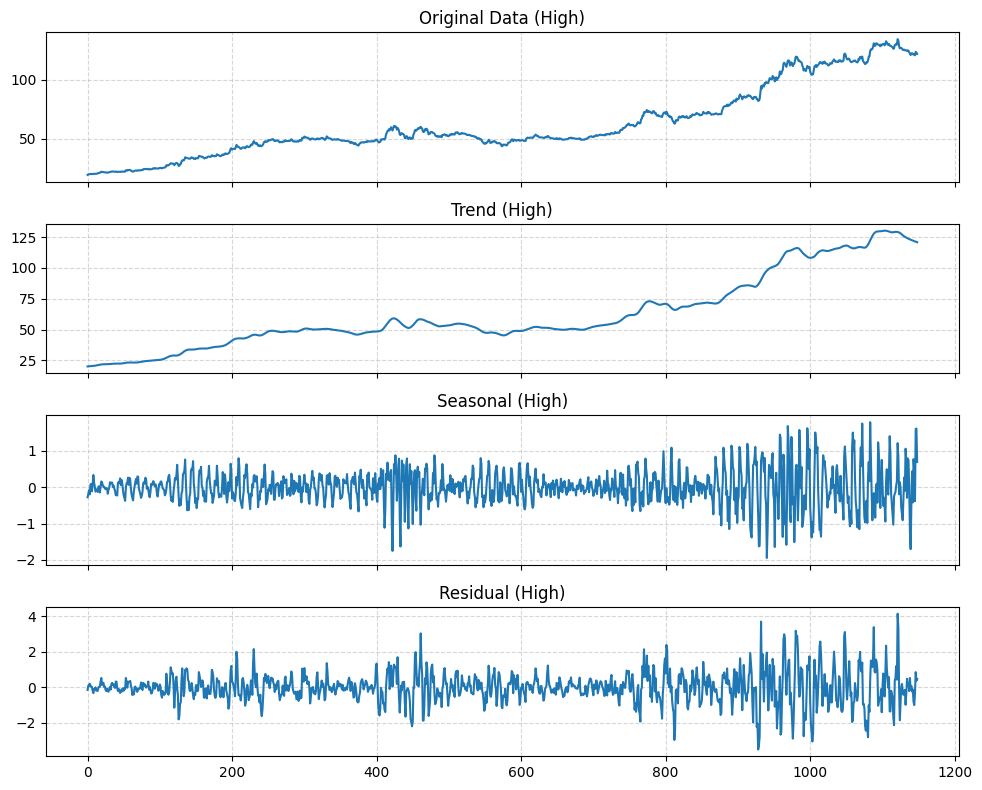

In [ ]:
stl_high = STL(analize['high'], period=11)
res_high = stl_high.fit()

fig_high, axes_high = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

analize['high'].plot(ax=axes_high[0])
axes_high[0].grid(True, linestyle='--', alpha=0.5)
axes_high[0].set_title('Original Data (High)')

res_high.trend.plot(ax=axes_high[1])
axes_high[1].grid(True, linestyle='--', alpha=0.5)
axes_high[1].set_title('Trend (High)')

res_high.seasonal.plot(ax=axes_high[2])
axes_high[2].grid(True, linestyle='--', alpha=0.5)
axes_high[2].set_title('Seasonal (High)')

res_high.resid.plot(ax=axes_high[3])
axes_high[3].grid(True, linestyle='--', alpha=0.5)
axes_high[3].set_title('Residual (High)')

plt.tight_layout()
plt.show()

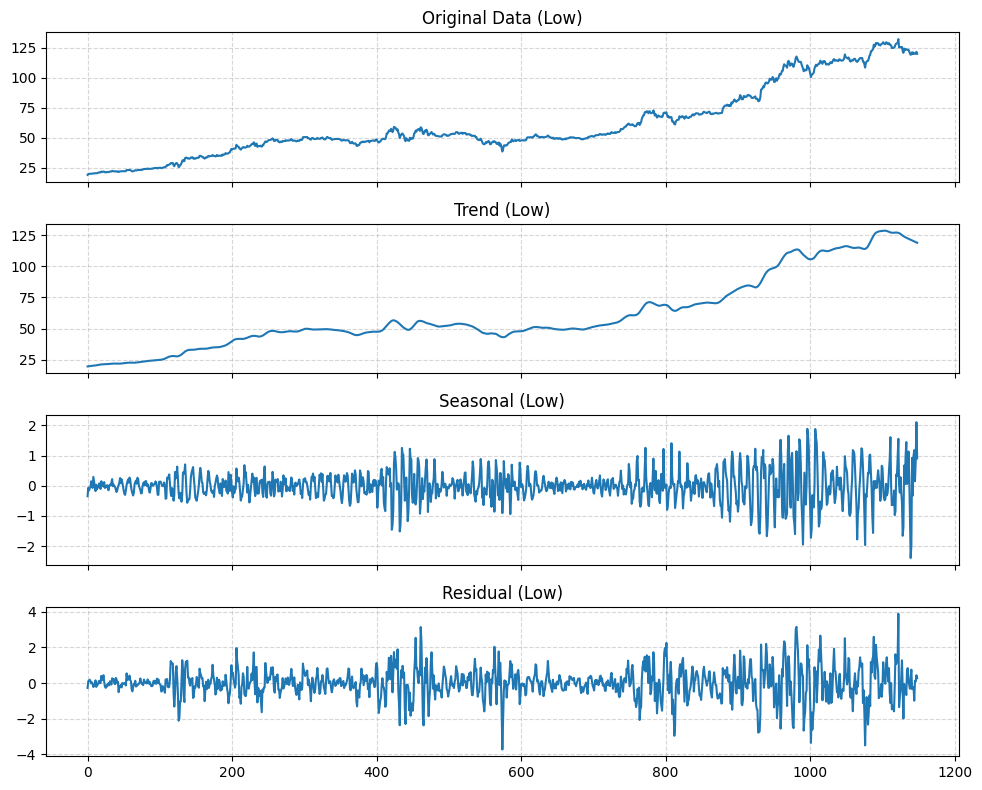

In [ ]:
stl_low = STL(analize['low'], period=11)
res_low = stl_low.fit()

fig_low, axes_low = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

analize['low'].plot(ax=axes_low[0])
axes_low[0].grid(True, linestyle='--', alpha=0.5)
axes_low[0].set_title('Original Data (Low)')

res_low.trend.plot(ax=axes_low[1])
axes_low[1].grid(True, linestyle='--', alpha=0.5)
axes_low[1].set_title('Trend (Low)')

res_low.seasonal.plot(ax=axes_low[2])
axes_low[2].grid(True, linestyle='--', alpha=0.5)
axes_low[2].set_title('Seasonal (Low)')

res_low.resid.plot(ax=axes_low[3])
axes_low[3].grid(True, linestyle='--', alpha=0.5)
axes_low[3].set_title('Residual (Low)')

plt.tight_layout()
plt.show()

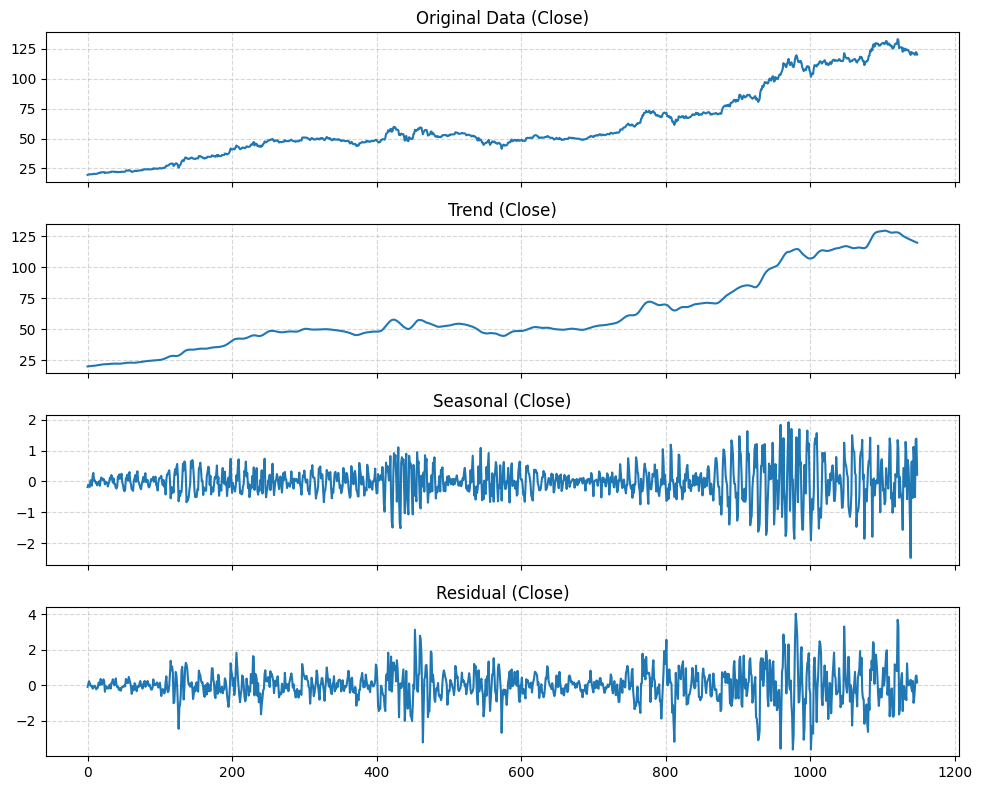

In [ ]:
stl_close = STL(analize['close'], period=11)
res_close = stl_close.fit()

fig_close, axes_close = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

analize['close'].plot(ax=axes_close[0])
axes_close[0].grid(True, linestyle='--', alpha=0.5)
axes_close[0].set_title('Original Data (Close)')

res_close.trend.plot(ax=axes_close[1])
axes_close[1].grid(True, linestyle='--', alpha=0.5)
axes_close[1].set_title('Trend (Close)')

res_close.seasonal.plot(ax=axes_close[2])
axes_close[2].grid(True, linestyle='--', alpha=0.5)
axes_close[2].set_title('Seasonal (Close)')

res_close.resid.plot(ax=axes_close[3])
axes_close[3].grid(True, linestyle='--', alpha=0.5)
axes_close[3].set_title('Residual (Close)')

plt.tight_layout()
plt.show()

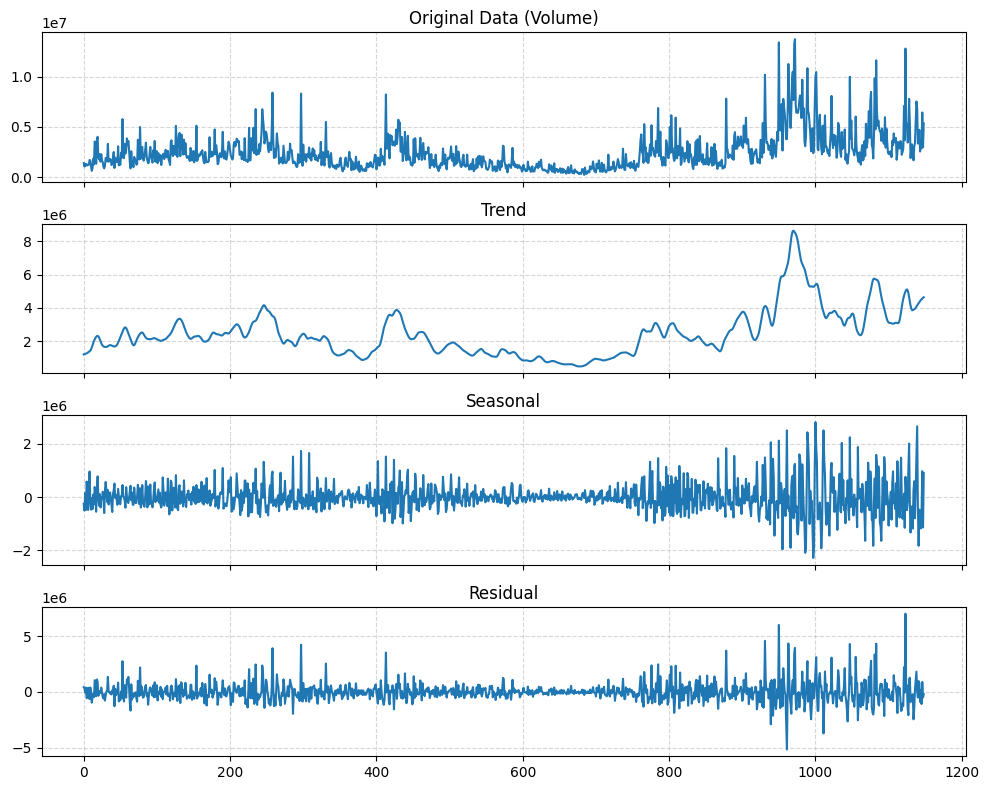

In [ ]:
stl_vol = STL(analize['volume'], period=11)
res_vol = stl_vol.fit()

fig_vol, axes_vol = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

analize['volume'].plot(ax=axes_vol[0])
axes_vol[0].grid(True, linestyle='--', alpha=0.5)
axes_vol[0].set_title('Original Data (Volume)')

res_vol.trend.plot(ax=axes_vol[1])
axes_vol[1].grid(True, linestyle='--', alpha=0.5)
axes_vol[1].set_title('Trend')

res_vol.seasonal.plot(ax=axes_vol[2])
axes_vol[2].grid(True, linestyle='--', alpha=0.5)
axes_vol[2].set_title('Seasonal')

res_vol.resid.plot(ax=axes_vol[3])
axes_vol[3].grid(True, linestyle='--', alpha=0.5)
axes_vol[3].set_title('Residual')

plt.tight_layout()
plt.show()

<Axes: title={'center': 'histogram about return'}>

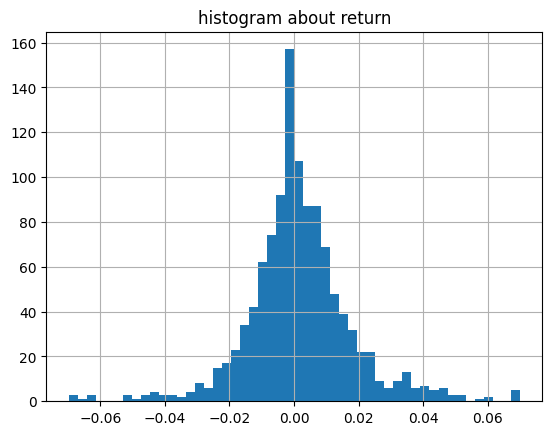

In [ ]:
plt.title("histogram about return")
df_train["close"].pct_change().hist(bins=50)

In [ ]:
df = df_train.copy()

df.drop("time", axis=1, inplace=True)

df["log_open"] = np.log(df["open"])
df["log_high"] = np.log(df["high"])
df["log_low"]  = np.log(df["low"])
df["log_close"] = np.log(df["close"])

df["diff_log_open"] = df["log_open"].diff()
df["diff_log_high"] = df["log_high"].diff()
df["diff_log_low"] = df["log_low"].diff()
df["diff_log_close"] = df["log_close"].diff()

# diff_cols = [col for col in df.columns if 'diff_' in col]
for col in [col for col in df.columns if 'diff_' in col]:
    df[col] = df[col].fillna(0)

In [ ]:
df.head()

,open,high,low,close,volume,log_open,log_high,log_low,log_close,diff_log_open,diff_log_high,diff_log_low,diff_log_close
0,19.07,19.63,19.03,19.63,1392200,2.948116,2.977059,2.946017,2.977059,0.000000,0.000000,0.000000,0.000000
1,19.89,20.01,19.76,19.91,1051310,2.990217,2.996232,2.983660,2.991222,0.042101,0.019173,0.037643,0.014163
2,19.89,20.16,19.78,20.10,1328520,2.990217,3.003700,2.984671,3.000720,0.000000,0.007468,0.001012,0.009498
3,20.10,20.21,19.97,20.01,1153660,3.000720,3.006178,2.994231,2.996232,0.010503,0.002477,0.009560,-0.004488
4,20.01,20.44,20.01,20.14,1283690,2.996232,3.017494,2.996232,3.002708,-0.004488,0.011316,0.002001,0.006476


<Axes: >

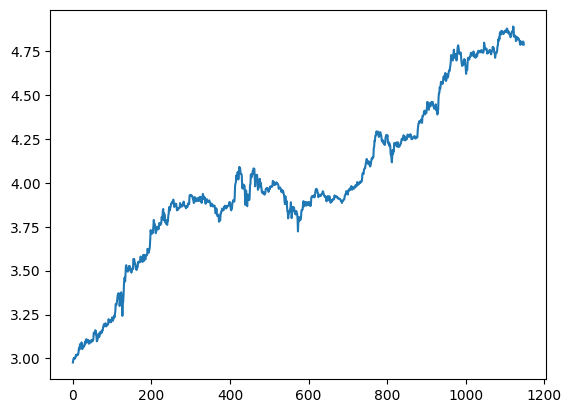

In [ ]:
df["log_close"].plot()

<Axes: ylabel='diff_log_close'>

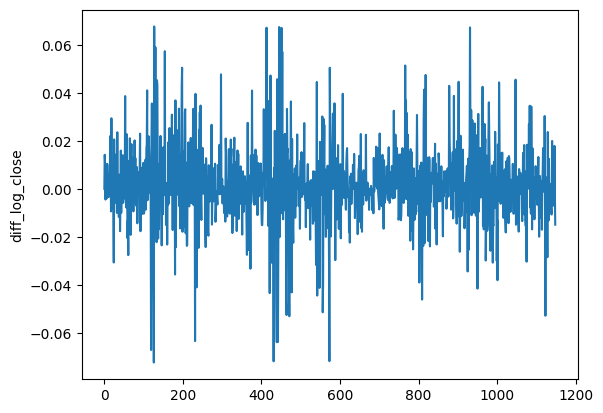

In [ ]:
plt.ylabel("diff_log_close")
df["diff_log_close"].plot()

In [ ]:
# Return (different timeframes)
df["return_1"] = df["close"].pct_change(1).shift(1)
df["return_5"] = df["close"].pct_change(5)
df["return_10"] = df["close"].pct_change(10)
df["return_20"] = df["close"].pct_change(20)

# Log returns (stable ver of Return)
df["log_return_1"] = np.log(df['close'] / df['close'].shift(1))
df['log_return_5'] = np.log(df['close'] / df['close'].shift(5))

for col in [col for col in df.columns if 'return_' in col]:
    df[col] = df[col].fillna(0)

In [ ]:
df.head()

,open,high,low,close,volume,log_open,log_high,log_low,log_close,diff_log_open,diff_log_high,diff_log_low,diff_log_close,return_1,return_5,return_10,return_20,log_return_1,log_return_5
0,19.07,19.63,19.03,19.63,1392200,2.948116,2.977059,2.946017,2.977059,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0
1,19.89,20.01,19.76,19.91,1051310,2.990217,2.996232,2.983660,2.991222,0.042101,0.019173,0.037643,0.014163,0.000000,0.0,0.0,0.0,0.014163,0.0
2,19.89,20.16,19.78,20.10,1328520,2.990217,3.003700,2.984671,3.000720,0.000000,0.007468,0.001012,0.009498,0.014264,0.0,0.0,0.0,0.009498,0.0
3,20.10,20.21,19.97,20.01,1153660,3.000720,3.006178,2.994231,2.996232,0.010503,0.002477,0.009560,-0.004488,0.009543,0.0,0.0,0.0,-0.004488,0.0
4,20.01,20.44,20.01,20.14,1283690,2.996232,3.017494,2.996232,3.002708,-0.004488,0.011316,0.002001,0.006476,-0.004478,0.0,0.0,0.0,0.006476,0.0


In [ ]:
# Price relationships (intraday patterns)
df['hl_ratio'] = (df['high'] - df['low']) / df['close']
df['co_ratio'] = (df['close'] - df['open']) / df['open']
df['body_ratio'] = abs(df['close'] - df['open']) / (df['high'] - df['low'] + 1e-8)
df['upper_shadow'] = (df['high'] - df[['open', 'close']].max(axis=1)) / df['close']
df['lower_shadow'] = (df[['open', 'close']].min(axis=1) - df['low']) / df['close']

for col in ['hl_ratio', 'co_ratio', 'body_ratio', 'upper_shadow', 'lower_shadow']:
    df[col] = df[col].ffill()

In [ ]:
df.head()

,open,high,low,close,volume,log_open,log_high,log_low,log_close,diff_log_open,...,return_5,return_10,return_20,log_return_1,log_return_5,hl_ratio,co_ratio,body_ratio,upper_shadow,lower_shadow
0,19.07,19.63,19.03,19.63,1392200,2.948116,2.977059,2.946017,2.977059,0.000000,...,0.0,0.0,0.0,0.000000,0.0,0.030565,0.029365,0.933333,0.000000,0.002038
1,19.89,20.01,19.76,19.91,1051310,2.990217,2.996232,2.983660,2.991222,0.042101,...,0.0,0.0,0.0,0.014163,0.0,0.012557,0.001006,0.080000,0.005023,0.006529
2,19.89,20.16,19.78,20.10,1328520,2.990217,3.003700,2.984671,3.000720,0.000000,...,0.0,0.0,0.0,0.009498,0.0,0.018905,0.010558,0.552632,0.002985,0.005473
3,20.10,20.21,19.97,20.01,1153660,3.000720,3.006178,2.994231,2.996232,0.010503,...,0.0,0.0,0.0,-0.004488,0.0,0.011994,-0.004478,0.375000,0.005497,0.001999
4,20.01,20.44,20.01,20.14,1283690,2.996232,3.017494,2.996232,3.002708,-0.004488,...,0.0,0.0,0.0,0.006476,0.0,0.021351,0.006497,0.302326,0.014896,0.000000


In [ ]:
# Moving averages
for window in [5, 10, 20, 50]:
    # Simple Moving Average
    df[f'sma_{window}'] = df['close'].rolling(window).mean()
    df[f'close_to_sma_{window}'] = (df['close'] - df[f'sma_{window}']) / df[f'sma_{window}']

    # Exponential Moving Average
    df[f'ema_{window}'] = df['close'].ewm(span=window, adjust=False).mean()
    df[f'close_to_ema_{window}'] = (df['close'] - df[f'ema_{window}']) / df[f'ema_{window}']

# Moving average crossovers (golden cross, death cross)
df['sma_5_20_cross'] = (df['sma_5'] - df['sma_20']) / df['close']
df['sma_10_50_cross'] = (df['sma_10'] - df['sma_50']) / df['close']

In [ ]:
# Votality features
for window in [5, 10, 20]:
    # Historical volatility
    df[f'volatility_{window}'] = df['return_1'].rolling(window).std()

    # Parkinson volatility (uses high-low)
    df[f'parkinson_vol_{window}'] = np.sqrt(
        (np.log(df['high'] / df['low']) ** 2).rolling(window).mean() / (4 * np.log(2))
    )

In [ ]:
# Bollinger Bands
for window in [10, 20]:
    rolling_mean = df['close'].rolling(window).mean()
    rolling_std = df['close'].rolling(window).std()
    df[f'bb_upper_{window}'] = rolling_mean + (2 * rolling_std)
    df[f'bb_lower_{window}'] = rolling_mean - (2 * rolling_std)
    df[f'bb_position_{window}'] = (df['close'] - df[f'bb_lower_{window}']) / \
                                  (df[f'bb_upper_{window}'] - df[f'bb_lower_{window}'] + 1e-8)
    df[f'bb_width_{window}'] = (df[f'bb_upper_{window}'] - df[f'bb_lower_{window}']) / rolling_mean

In [ ]:
#  Momentum indicators
# RSI (Relative Strength Index)
for window in [14, 28]:
    delta = df['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
    rs = gain / (loss + 1e-8)
    df[f'rsi_{window}'] = 100 - (100 / (1 + rs))

In [ ]:
# MACD (Moving Average Convergence Divergence)
exp1 = df['close'].ewm(span=12, adjust=False).mean()
exp2 = df['close'].ewm(span=26, adjust=False).mean()
df['macd'] = exp1 - exp2
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
df['macd_diff'] = df['macd'] - df['macd_signal']
df['macd_normalized'] = df['macd'] / df['close']

In [ ]:
# Stochastic Oscillator
for window in [14]:
    low_min = df['low'].rolling(window).min()
    high_max = df['high'].rolling(window).max()
    df[f'stoch_{window}'] = 100 * (df['close'] - low_min) / (high_max - low_min + 1e-8)
    df[f'stoch_signal_{window}'] = df[f'stoch_{window}'].rolling(3).mean()

In [ ]:
# Rate of Change (ROC)
for window in [5, 10, 20]:
    df[f'roc_{window}'] = ((df['close'] - df['close'].shift(window)) / df['close'].shift(window)) * 100

In [ ]:
df = df.ffill().fillna(0)

In [ ]:
df.head()

,open,high,low,close,volume,log_open,log_high,log_low,log_close,diff_log_open,...,rsi_28,macd,macd_signal,macd_diff,macd_normalized,stoch_14,stoch_signal_14,roc_5,roc_10,roc_20
0,19.07,19.63,19.03,19.63,1392200,2.948116,2.977059,2.946017,2.977059,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1,19.89,20.01,19.76,19.91,1051310,2.990217,2.996232,2.983660,2.991222,0.042101,...,0.0,0.022336,0.004467,0.017869,0.001122,0.0,0.0,0.0,0.0,0.0
2,19.89,20.16,19.78,20.10,1328520,2.990217,3.003700,2.984671,3.000720,0.000000,...,0.0,0.054738,0.014521,0.040217,0.002723,0.0,0.0,0.0,0.0,0.0
3,20.10,20.21,19.97,20.01,1153660,3.000720,3.006178,2.994231,2.996232,0.010503,...,0.0,0.072321,0.026081,0.046240,0.003614,0.0,0.0,0.0,0.0,0.0
4,20.01,20.44,20.01,20.14,1283690,2.996232,3.017494,2.996232,3.002708,-0.004488,...,0.0,0.095643,0.039994,0.055649,0.004749,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Volume feature
# Volume changes
df['volume_change'] = df['volume'].pct_change()
df['log_volume'] = np.log(df['volume'] + 1)
df['volume_return_1'] = df['log_volume'].diff()

df = df.fillna(0)

In [ ]:
# Volume moving averages
for window in [5, 10, 20]:
    df[f'volume_sma_{window}'] = df['volume'].rolling(window).mean()
    df[f'volume_ratio_{window}'] = df['volume'] / (df[f'volume_sma_{window}'] + 1)
    df[f'volume_std_{window}'] = df['volume'].rolling(window).std()

# Price-Volume relationship
df['price_volume'] = df['return_1'] * df['volume_change']
df['obv'] = (np.sign(df['close'].diff()) * df['volume']).cumsum()  # On-Balance Volume
df['obv_normalized'] = df['obv'] / df['obv'].rolling(20).mean()

# Volume-weighted average price (VWAP)
df['vwap'] = (df['volume'] * (df['high'] + df['low'] + df['close']) / 3).cumsum() / df['volume'].cumsum()
df['close_to_vwap'] = (df['close'] - df['vwap']) / df['vwap']

# Money Flow Index (MFI)
typical_price = (df['high'] + df['low'] + df['close']) / 3
money_flow = typical_price * df['volume']

positive_flow = money_flow.where(typical_price > typical_price.shift(1), 0).rolling(14).sum()
negative_flow = money_flow.where(typical_price < typical_price.shift(1), 0).rolling(14).sum()
mfi_ratio = positive_flow / (negative_flow + 1e-8)
df['mfi'] = 100 - (100 / (1 + mfi_ratio))

In [ ]:
# Trend features

# ADX (Average Directional Index) - Trend strength
high_low = df['high'] - df['low']
high_close = abs(df['high'] - df['close'].shift())
low_close = abs(df['low'] - df['close'].shift())
true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
df['atr_14'] = true_range.rolling(14).mean()
df['atr_normalized'] = df['atr_14'] / df['close']

# Price position in recent range
for window in [10, 20, 50]:
    df[f'price_position_{window}'] = (df['close'] - df['close'].rolling(window).min()) / \
                                      (df['close'].rolling(window).max() - df['close'].rolling(window).min() + 1e-8)
df = df.ffill().fillna(0)

In [ ]:
# Pattern features
# Higher highs, lower lows
df['higher_high'] = (df['high'] > df['high'].shift(1)).astype(int)
df['lower_low'] = (df['low'] < df['low'].shift(1)).astype(int)

# Gap detection
df['gap_up'] = (df['low'] > df['high'].shift(1)).astype(int)
df['gap_down'] = (df['high'] < df['low'].shift(1)).astype(int)

In [ ]:
# Time-based features
if 'time' in df.columns:
    df['time'] = pd.to_datetime(df['time'])
    df['day_of_week'] = df['time'].dt.dayofweek
    df['day_of_month'] = df['time'].dt.day
    df['month'] = df['time'].dt.month
    df['quarter'] = df['time'].dt.quarter

    # Cyclical encoding for time features
    df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

In [ ]:
df.head()

,open,high,low,close,volume,log_open,log_high,log_low,log_close,diff_log_open,...,mfi,atr_14,atr_normalized,price_position_10,price_position_20,price_position_50,higher_high,lower_low,gap_up,gap_down
0,19.07,19.63,19.03,19.63,1392200,2.948116,2.977059,2.946017,2.977059,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0
1,19.89,20.01,19.76,19.91,1051310,2.990217,2.996232,2.983660,2.991222,0.042101,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1,0
2,19.89,20.16,19.78,20.10,1328520,2.990217,3.003700,2.984671,3.000720,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0
3,20.10,20.21,19.97,20.01,1153660,3.000720,3.006178,2.994231,2.996232,0.010503,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0
4,20.01,20.44,20.01,20.14,1283690,2.996232,3.017494,2.996232,3.002708,-0.004488,...,0.0,0.0,0.0,0.0,0.0,0.0,1,0,0,0


In [ ]:
# Lag features
lag_fea = pd.DataFrame(index=df.index)

for lag in [1, 2, 3, 5]:
    lag_fea[f'close_lag_{lag}'] = df['close'].shift(lag)
    lag_fea[f'volume_lag_{lag}'] = df['volume'].shift(lag)
    lag_fea[f'return_lag_{lag}'] = df['return_1'].shift(lag)

lag_fea = lag_fea.ffill().fillna(0)

# Concatenate the new features to the original DataFrame
df = pd.concat([df, lag_fea], axis=1)

In [ ]:
# Statistical feature

for window in [5, 10, 20]:
    # Skewness and Kurtosis of returns
    df[f'return_skew_{window}'] = df['return_1'].rolling(window).skew()
    df[f'return_kurt_{window}'] = df['return_1'].rolling(window).kurt()

    # Z-score of price
    rolling_mean = df['close'].rolling(window).mean()
    rolling_std = df['close'].rolling(window).std()
    df[f'price_zscore_{window}'] = (df['close'] - rolling_mean) / (rolling_std + 1e-8)

In [ ]:
df["scaled_log_open"] = (df["log_open"] - df["log_open"].rolling(10).mean()) / df["log_open"].rolling(10).std()
df["scaled_log_high"] = (df["log_high"] - df["log_high"].rolling(10).mean()) / df["log_high"].rolling(10).std()
df["scaled_log_low"] = (df["log_low"] - df["log_low"].rolling(10).mean()) / df["log_low"].rolling(10).std()
df["scaled_log_close"] = (df["log_close"] - df["log_close"].rolling(10).mean()) / df["log_close"].rolling(10).std()

df = df.ffill().fillna(0)

In [ ]:
# A. Recent volatility regime
df['vol_regime'] = (df['volatility_20'] > df['volatility_20'].rolling(60).mean()).astype(int)

# B. Trend strength
df['trend_strength'] = abs(df['close'].rolling(20).mean() - df['close'].rolling(50).mean()) / df['close']

# C. Mean reversion indicator
df['mean_reversion'] = (df['close'] - df['close'].rolling(100).mean()) / df['close'].rolling(100).std()

# D. Momentum regime
df['momentum_regime'] = (df['return_5'].rolling(20).mean() > 0).astype(int)

df = df.ffill().fillna(0)

In [ ]:
df.head()

,open,high,low,close,volume,log_open,log_high,log_low,log_close,diff_log_open,...,return_kurt_20,price_zscore_20,scaled_log_open,scaled_log_high,scaled_log_low,scaled_log_close,vol_regime,trend_strength,mean_reversion,momentum_regime
0,19.07,19.63,19.03,19.63,1392200,2.948116,2.977059,2.946017,2.977059,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0
1,19.89,20.01,19.76,19.91,1051310,2.990217,2.996232,2.983660,2.991222,0.042101,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0
2,19.89,20.16,19.78,20.10,1328520,2.990217,3.003700,2.984671,3.000720,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0
3,20.10,20.21,19.97,20.01,1153660,3.000720,3.006178,2.994231,2.996232,0.010503,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0
4,20.01,20.44,20.01,20.14,1283690,2.996232,3.017494,2.996232,3.002708,-0.004488,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0


In [ ]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [ ]:
class MovingAvg(nn.Module):
    def __init__(self, kernel_size, stride=1):
        super(MovingAvg, self).__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        # x: (batch, seq_len, channels)
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = self.avg(x.permute(0, 2, 1)) # (batch, channels, seq_len)
        x = x.permute(0, 2, 1) # (batch, seq_len, channels)
        return x

class SeriesDecomposition(nn.Module):
    def __init__(self, kernel_size):
        super(SeriesDecomposition, self).__init__()
        self.moving_avg = MovingAvg(kernel_size, stride=1)

    def forward(self, x):
        # x: (batch, seq_len, channels)
        trend = self.moving_avg(x)
        seasonal = x - trend
        return trend, seasonal

In [ ]:
class DLinear(nn.Module):
    def __init__(self, seq_len, pred_len, channels, individual=False,
                 kernel_size=25, dropout=0.1):
        super(DLinear, self).__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.channels = channels
        self.individual = individual

        self.decomposition = SeriesDecomposition(kernel_size)

        if individual:
            self.Linear_Seasonal = nn.ModuleList([
                nn.Linear(seq_len, pred_len) for _ in range(channels)
            ])
            self.Linear_Trend = nn.ModuleList([
                nn.Linear(seq_len, pred_len) for _ in range(channels)
            ])
        else:
           self.Linear_Seasonal = nn.Linear(seq_len, pred_len)
           self.Linear_Trend = nn.Linear(seq_len, pred_len)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch, seq_len, channels)
        seasonal, trend = self.decomposition(x)

        if self.individual:
            seasonal_output = torch.zeros([x.size(0), self.pred_len, self.channels],
                                          dtype=x.dtype, device=x.device)
            trend_output = torch.zeros([x.size(0), self.pred_len, self.channels],
                                       dtype=x.dtype, device=x.device)
            for i in range(self.channels):
                seasonal_output[:, :, i] = self.Linear_Seasonal[i](seasonal[:, :, i])
                trend_output[:, :, i] = self.Linear_Trend[i](trend[:, :, i])
        else:
            # (batch, seq_len, channels) => (batch, channels, seq_len)
            seasonal = seasonal.permute(0, 2, 1)
            trend = trend.permute(0, 2, 1)

            seasonal_output = self.Linear_Seasonal(seasonal)
            trend_output = self.Linear_Trend(trend)

            # (batch, channels, seq_len) => (batch, seq_len, channels)
            seasonal_output = seasonal_output.permute(0, 2, 1)
            trend_output = trend_output.permute(0, 2, 1)

        output = seasonal_output + trend_output
        output = self.dropout(output)
        return output

In [ ]:
class NLinear(nn.Module):
    def __init__(self, seq_len, pred_len, channels, individual=False, dropout=0.1):
        super(NLinear, self).__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.channels = channels
        self.individual = individual

        if individual:
            self.Linear = nn.ModuleList([
                nn.Linear(seq_len, pred_len) for _ in range(channels)
            ])
        else:
            self.Linear = nn.Linear(seq_len, pred_len)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch, seq_len, channels)

        # Normalization
        seq_last = x[:, -1:, :].detach()  # (batch, 1, channels)
        x = x - seq_last

        if self.individual:
            output = torch.zeros([x.size(0), self.pred_len, self.channels],
                                dtype=x.dtype, device=x.device)
            for i in range(self.channels):
                output[:, :, i] = self.Linear[i](x[:, :, i])
        else:
            # (batch, seq_len, channels) -> (batch, channels, seq_len)
            x = x.permute(0, 2, 1)
            output = self.Linear(x)  # (batch, channels, pred_len)
            output = output.permute(0, 2, 1)  # (batch, pred_len, channels)

        output = self.dropout(output)

        # Denormalization
        output = output + seq_last

        return output

In [ ]:
class EnhancedDLinear(nn.Module):
    def __init__(self, seq_len, pred_len, channels, individual=False,
                 kernel_sizes=[25, 49], dropout=0.1, use_attention=True):
        super(EnhancedDLinear, self).__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.channels = channels
        self.use_attention = use_attention

        # Multi-scale decomposition
        self.decompositions = nn.ModuleList([
            SeriesDecomposition(k) for k in kernel_sizes
        ])

        # Linear layers for each scale
        self.seasonal_linears = nn.ModuleList([
            nn.Linear(seq_len, pred_len) for _ in kernel_sizes
        ])
        self.trend_linears = nn.ModuleList([
            nn.Linear(seq_len, pred_len) for _ in kernel_sizes
        ])

        # Channel attention
        if use_attention:
            self.channel_attention = nn.Sequential(
                nn.Linear(channels, channels // 2),
                nn.ReLU(),
                nn.Linear(channels // 2, channels),
                nn.Sigmoid()
            )

        # Residual projection
        self.residual_proj = nn.Linear(seq_len, pred_len)

        # Layer normalization
        self.norm = nn.LayerNorm(channels)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch, seq_len, channels)
        batch_size = x.size(0)

        # Residual
        residual = x.permute(0, 2, 1)  # (batch, channels, seq_len)
        residual = self.residual_proj(residual).permute(0, 2, 1)  # (batch, pred_len, channels)

        # Multi-scale decomposition
        outputs = []
        for decomp, seasonal_linear, trend_linear in zip(
            self.decompositions, self.seasonal_linears, self.trend_linears
        ):
            seasonal, trend = decomp(x)

            seasonal = seasonal.permute(0, 2, 1)
            trend = trend.permute(0, 2, 1)

            seasonal_out = seasonal_linear(seasonal).permute(0, 2, 1)
            trend_out = trend_linear(trend).permute(0, 2, 1)

            outputs.append(seasonal_out + trend_out)

        # Combine multi-scale outputs
        output = torch.stack(outputs, dim=0).mean(dim=0)  # Average across scales

        # Channel attention
        if self.use_attention:
            channel_weights = output.mean(dim=1)  # (batch, channels)
            channel_weights = self.channel_attention(channel_weights)  # (batch, channels)
            output = output * channel_weights.unsqueeze(1)  # (batch, pred_len, channels)

        # Add residual
        output = output + residual

        # Normalize and dropout
        output = self.norm(output)
        output = self.dropout(output)

        return output

In [ ]:
class EnhancedNLinear(nn.Module):
    def __init__(self, seq_len, pred_len, channels, individual=False,
                 dropout=0.1, use_revin=True):
        super(EnhancedNLinear, self).__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.channels = channels
        self.use_revin = use_revin

        if use_revin:
            self.revin_layer = RevIN(channels, affine=True)

        # MLP
        hidden_size = seq_len
        self.projection = nn.Sequential(
            nn.Linear(seq_len, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, pred_len)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch, seq_len, channels)

        if self.use_revin:
            x = self.revin_layer(x, mode='norm')

        # Project: (batch, seq_len, channels) -> (batch, channels, seq_len)
        x = x.permute(0, 2, 1)
        output = self.projection(x)  # (batch, channels, pred_len)
        output = output.permute(0, 2, 1)  # (batch, pred_len, channels)

        output = self.dropout(output)

        if self.use_revin:
            output = self.revin_layer(output, mode='denorm')

        return output

In [ ]:
class RevIN(nn.Module):
    def __init__(self, num_features, eps=1e-5, affine=True):
        super(RevIN, self).__init__()
        self.num_features = num_features
        self.eps = eps
        self.affine = affine

        if affine:
            self.affine_weight = nn.Parameter(torch.ones(num_features))
            self.affine_bias = nn.Parameter(torch.zeros(num_features))

    def forward(self, x, mode='norm'):
        # x: (batch, seq_len, channels)

        if mode == 'norm':
            # Normalize
            self.mean = x.mean(dim=1, keepdim=True).detach()  # (batch, 1, channels)
            self.std = torch.sqrt(x.var(dim=1, keepdim=True, unbiased=False) + self.eps).detach()
            x = (x - self.mean) / self.std

            if self.affine:
                x = x * self.affine_weight + self.affine_bias

        elif mode == 'denorm':
            # Denormalize
            if self.affine:
                x = (x - self.affine_bias) / (self.affine_weight + self.eps)
            x = x * self.std + self.mean

        return x

In [ ]:
class HybridModel(nn.Module):
    def __init__(self, seq_len, pred_len, channels, dropout=0.1):
        super(HybridModel, self).__init__()

        self.dlinear = EnhancedDLinear(
            seq_len, pred_len, channels,
            kernel_sizes=[25, 49],
            dropout=dropout,
            use_attention=True
        )

        self.nlinear = EnhancedNLinear(
            seq_len, pred_len, channels,
            dropout=dropout,
            use_revin=True
        )

        self.alpha = nn.Parameter(torch.tensor(0.5))

    def forward(self, x):
        dlinear_out = self.dlinear(x)
        nlinear_out = self.nlinear(x)

        # Weighted combination
        alpha = torch.sigmoid(self.alpha)
        output = alpha * dlinear_out + (1 - alpha) * nlinear_out

        return output

In [ ]:
class TimeSeriesDataset(Dataset):
    """Dataset for DLinear/NLinear"""
    def __init__(self, df, features, seq_len, pred_len, target_idx=0):
        self.df = df
        self.features = features
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.target_idx = target_idx

    def __len__(self):
        return len(self.df) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        # Input: (seq_len, channels)
        X_data = self.df.iloc[idx : idx + self.seq_len][self.features].values

        y_data = self.df.iloc[idx + self.seq_len : idx + self.seq_len + self.pred_len]['close'].values

        return torch.from_numpy(X_data).float(), torch.from_numpy(y_data).float()

def create_datasets(df, features, seq_lengths, pred_len, target):
    datasets = {}
    for seq_len in seq_lengths:
        datasets[f'{seq_len}'] = TimeSeriesDataset(
                                df=df, feature_cols=features, target_cols=target,
                                seq_len=seq_len, pred_len=pred_len)
    return datasets

In [ ]:
class EarlyStopping:
    def __init__(self, patience=15, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [ ]:
class MultiModelTrainer:
    def __init__(self, device, config):
        self.device = device
        self.config = config
        self.models = {}
        self.feature_stats = None
        self.training_history = {}

    def normalize_features(self, df, features, fit=True):
        df_norm = df.copy()

        if fit:
            self.feature_stats = {}
            for feature in features:
                self.feature_stats[feature] = {
                    'mean': df[feature].mean(),
                    'std': df[feature].std() + 1e-8
                }

        for feature in features:
            mean = self.feature_stats[feature]['mean']
            std = self.feature_stats[feature]['std']
            df_norm[feature] = (df[feature] - mean) / std

        return df_norm

    def train_single_model(self, seq_len, seed, train_loader, val_loader, model_type='dlinear'):
        set_seed(seed)

        if model_type == 'dlinear':
            model = DLinear(
                seq_len=seq_len,
                pred_len=self.config['pred_len'],
                channels=len(self.config['features']),
                individual=False,
                dropout=self.config['dropout']
            )
        elif model_type == 'nlinear':
            model = NLinear(
                seq_len=seq_len,
                pred_len=self.config['pred_len'],
                channels=len(self.config['features']),
                individual=False,
                dropout=self.config['dropout']
            )
        elif model_type == 'enhanced_dlinear':
            model = EnhancedDLinear(
                seq_len=seq_len,
                pred_len=self.config['pred_len'],
                channels=len(self.config['features']),
                kernel_sizes=[25, 49],
                dropout=self.config['dropout'],
                use_attention=True
            )
        elif model_type == 'enhanced_nlinear':
            model = EnhancedNLinear(
                seq_len=seq_len,
                pred_len=self.config['pred_len'],
                channels=len(self.config['features']),
                dropout=self.config['dropout'],
                use_revin=True
            )
        elif model_type == 'hybrid':
            model = HybridModel(
                seq_len=seq_len,
                pred_len=self.config['pred_len'],
                channels=len(self.config['features']),
                dropout=self.config['dropout']
            )

        model = model.to(self.device)

        criterion = nn.MSELoss()
        optimizer = optim.Adam(
            model.parameters(),
            lr=self.config['lr'],
            weight_decay=self.config['weight_decay']
        )
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=self.config['epochs']
        )

        early_stopping = EarlyStopping(patience=self.config['patience'])

        best_val_loss = float('inf')
        best_model_state = None

        train_losses = []
        val_losses = []

        print(f"\nTraining {model_type} - seq_len={seq_len}, seed={seed}")

        for epoch in range(self.config['epochs']):
            model.train()
            train_loss = 0.0
            for X, y in train_loader:
                X, y = X.to(self.device), y.to(self.device)
                optimizer.zero_grad()

                output = model(X)[:, :, 0]
                loss = criterion(output, y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                train_loss += loss.item()
            train_loss /= len(train_loader)
            train_losses.append(train_loss)

            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for X, y in val_loader:
                    X, y = X.to(self.device), y.to(self.device)
                    output = model(X)[:, :, 0]
                    loss = criterion(output, y)
                    val_loss += loss.item()
            val_loss /= len(val_loader)
            val_losses.append(val_loss)

            scheduler.step()

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = model.state_dict().copy()

            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{self.config['epochs']} - "
                      f"Train: {train_loss:.6f}, Val: {val_loss:.6f}")

            early_stopping(val_loss)
            if early_stopping.early_stop:
                print(f"Early stopping at epoch {epoch+1}")
                break

        model.load_state_dict(best_model_state)
        print(f"Best val loss: {best_val_loss:.6f}")

        key = (model_type, seq_len, seed)
        self.training_history[key] = {
            'train_losses': train_losses,
            'val_losses': val_losses,
            'best_val_loss': best_val_loss
        }

        return model, best_val_loss

    def train_all_models(self, df, features, seq_lengths, seeds, model_types=['dlinear', 'nlinear']):
        train_size = int(len(df) * self.config['train_split'])
        train_df = df[:train_size].copy()
        val_df = df[train_size:].copy()

        train_df = self.normalize_features(train_df, features, fit=True)
        val_df = self.normalize_features(val_df, features, fit=False)

        print(f"\nDataset: Train={len(train_df)}, Val={len(val_df)}")
        print("=" * 70)

        target_idx = features.index('close')

        for model_type in model_types:
            for seq_len in seq_lengths:
                for seed in seeds:
                    train_dataset = TimeSeriesDataset(
                        train_df, features, seq_len, self.config['pred_len'], target_idx
                    )
                    val_dataset = TimeSeriesDataset(
                        val_df, features, seq_len, self.config['pred_len'], target_idx
                    )

                    train_loader = DataLoader(
                        train_dataset,
                        batch_size=self.config['batch_size'],
                        shuffle=True,
                        num_workers=2,
                        pin_memory=True,
                    )
                    val_loader = DataLoader(
                        val_dataset,
                        batch_size=self.config['batch_size'],
                        shuffle=False,
                        num_workers=2,
                        pin_memory=True,
                    )

                    model, val_loss = self.train_single_model(
                        seq_len, seed, train_loader, val_loader, model_type
                    )

                    self.models[(model_type, seq_len, seed)] = {
                        'model': model,
                        'val_loss': val_loss
                    }

        print("\nTraining Summary")
        for key, info in sorted(self.models.items()):
            model_type, seq_len, seed = key
            print(f"{model_type:20s} seq_len={seq_len:3d} seed={seed:4d} -> Val: {info['val_loss']:.6f}")

    def train_with_walk_forward(self, df, features, seq_lengths, seeds, model_types=['dlinear', 'nlinear'], n_splits=5):
        """
        Train models using walk-forward validation
        Each fold uses progressively more training data
        """
        total_len = len(df)
        fold_size = total_len // (n_splits + 1)

        print(f"\n{'='*70}")
        print(f"WALK-FORWARD VALIDATION: {n_splits} splits")
        print(f"Total samples: {total_len}, Fold size: {fold_size}")
        print(f"{'='*70}")

        target_idx = features.index('close')
        fold_models = []

        for fold in range(n_splits):
            train_end = fold_size * (fold + 2)
            val_start = train_end
            val_end = min(train_end + fold_size, total_len)

            train_df = df[:train_end].copy()
            val_df = df[val_start:val_end].copy()

            print(f"\n--- FOLD {fold + 1}/{n_splits} ---")
            print(f"Train: 0 to {train_end} ({len(train_df)} samples)")
            print(f"Val: {val_start} to {val_end} ({len(val_df)} samples)")

            # Normalize
            train_df = self.normalize_features(train_df, features, fit=True)
            val_df = self.normalize_features(val_df, features, fit=False)

            # Store feature stats for this fold
            fold_feature_stats = self.feature_stats.copy()

            # Train models for this fold
            for model_type in model_types:
                for seq_len in seq_lengths:
                    for seed in seeds:
                        train_dataset = TimeSeriesDataset(
                            train_df, features, seq_len, self.config['pred_len'], target_idx
                        )
                        val_dataset = TimeSeriesDataset(
                            val_df, features, seq_len, self.config['pred_len'], target_idx
                        )

                        train_loader = DataLoader(
                            train_dataset,
                            batch_size=self.config['batch_size'],
                            shuffle=True,
                            num_workers=2,
                            pin_memory=True,
                        )
                        val_loader = DataLoader(
                            val_dataset,
                            batch_size=self.config['batch_size'],
                            shuffle=False,
                            num_workers=2,
                            pin_memory=True,
                        )

                        model, val_loss = self.train_single_model(
                            seq_len, seed, train_loader, val_loader, model_type
                        )

                        # Store with fold info
                        key = (model_type, seq_len, seed, fold)
                        fold_models.append({
                            'key': key,
                            'model': model,
                            'val_loss': val_loss,
                            'feature_stats': fold_feature_stats
                        })

        # Store all fold models
        self.fold_models = fold_models

        print(f"\n{'='*70}")
        print(f"Walk-forward training complete: {len(fold_models)} total models")
        print(f"{'='*70}")

        return fold_models

    def generate_ensemble_prediction(self, df, features, return_individual=False):
        print("\n" + "="*70)
        print("GENERATING ENSEMBLE PREDICTIONS")
        print("="*70)

        df_norm = self.normalize_features(df, features, fit=False)
        all_predictions = []

        for (model_type, seq_len, seed), info in self.models.items():
            model = info['model']
            model.eval()

            recent_data = df_norm[features].tail(seq_len).values
            input_tensor = torch.from_numpy(recent_data).float().unsqueeze(0).to(self.device)

            with torch.no_grad():
                predictions_normalized = model(input_tensor).cpu().numpy()[0]
                predictions_normalized = predictions_normalized[:, 0]

            close_mean = self.feature_stats['close']['mean']
            close_std = self.feature_stats['close']['std']
            predictions = predictions_normalized * close_std + close_mean

            all_predictions.append(predictions)

            print(f"{model_type:20s} seq={seq_len:3d} seed={seed:4d} -> "
                  f"First: {predictions[0]:.2f}, Last: {predictions[-1]:.2f}")

        all_predictions_array = np.array(all_predictions)
        final_predictions = np.mean(all_predictions_array, axis=0)

        last_actual = df['close'].iloc[-1]
        print(f"\nLast actual price: {last_actual:.2f}")
        print(f"First prediction: {final_predictions[0]:.2f}")
        print(f"Last prediction: {final_predictions[-1]:.2f}")
        print(f"Total change: {((final_predictions[-1] / last_actual) - 1) * 100:.2f}%")
        print("="*70)

        if return_individual:
            return final_predictions, all_predictions_array
        return final_predictions

    def generate_weighted_ensemble_prediction(self, df, features, return_individual=False,
                                             use_inverse_loss=True, top_k=None):
        print("\n" + "="*70)
        print("GENERATING WEIGHTED ENSEMBLE PREDICTIONS")
        print("="*70)

        df_norm = self.normalize_features(df, features, fit=False)

        all_predictions = []
        all_weights = []
        model_info = []

        # Collect all predictions and losses
        for (model_type, seq_len, seed), info in self.models.items():
            model = info['model']
            val_loss = info['val_loss']
            model.eval()

            recent_data = df_norm[features].tail(seq_len).values
            input_tensor = torch.from_numpy(recent_data).float().unsqueeze(0).to(self.device)

            with torch.no_grad():
                predictions_normalized = model(input_tensor).cpu().numpy()[0]
                predictions_normalized = predictions_normalized[:, 0]

            close_mean = self.feature_stats['close']['mean']
            close_std = self.feature_stats['close']['std']
            predictions = predictions_normalized * close_std + close_mean

            all_predictions.append(predictions)
            model_info.append({
                'type': model_type,
                'seq_len': seq_len,
                'seed': seed,
                'val_loss': val_loss,
                'predictions': predictions
            })

        # Sort by validation loss
        model_info.sort(key=lambda x: x['val_loss'])

        # Select top k models if specified
        if top_k is not None:
            model_info = model_info[:top_k]
            print(f"Using top {top_k} models by validation performance")

        # Calculate weights
        val_losses = np.array([m['val_loss'] for m in model_info])

        if use_inverse_loss:
            # Inverse weighting
            weights = 1.0 / (val_losses + 1e-6)
        else:
            # Softmax weighting (more extreme)
            neg_losses = -val_losses
            weights = np.exp(neg_losses - neg_losses.max())

        # Normalize weights
        weights = weights / weights.sum()

        # Print weight distribution
        print(f"\nModel Weights (using {'inverse loss' if use_inverse_loss else 'softmax'}):")
        for i, m in enumerate(model_info):
            print(f"{m['type']:20s} seq={m['seq_len']:3d} seed={m['seed']:4d} "
                  f"val_loss={m['val_loss']:.6f} -> weight={weights[i]:.4f}")

        # Weighted average
        predictions_array = np.array([m['predictions'] for m in model_info])
        final_predictions = np.average(predictions_array, axis=0, weights=weights)

        last_actual = df['close'].iloc[-1]
        print(f"\nLast actual price: {last_actual:.2f}")
        print(f"First prediction: {final_predictions[0]:.2f}")
        print(f"Last prediction: {final_predictions[-1]:.2f}")
        print(f"Total change: {((final_predictions[-1] / last_actual) - 1) * 100:.2f}%")
        print("="*70)

        if return_individual:
            return final_predictions, predictions_array
        return final_predictions

    def generate_conservative_prediction(self, df, features, damping_factor=0.95,
                                        reversion_window=20, use_weighted=True):
        print("\n" + "="*70)
        print("GENERATING CONSERVATIVE PREDICTIONS")
        print(f"Damping factor: {damping_factor}, Reversion window: {reversion_window}")
        print("="*70)

        # Get base predictions
        if use_weighted:
            predictions = self.generate_weighted_ensemble_prediction(df, features)
        else:
            predictions = self.generate_ensemble_prediction(df, features)

        last_price = df['close'].iloc[-1]
        mean_price = df['close'].tail(reversion_window).mean()

        print(f"\nApplying dampening:")
        print(f"Last price: {last_price:.2f}")
        print(f"Mean price ({reversion_window}-day): {mean_price:.2f}")

        # Apply exponential dampening
        dampened_predictions = []
        for i in range(len(predictions)):
            # Damping increases with time horizon
            damping = damping_factor ** (i + 1)

            # Gradually revert to historical mean
            dampened_pred = (damping * predictions[i] +
                           (1 - damping) * mean_price)
            dampened_predictions.append(dampened_pred)

        dampened_predictions = np.array(dampened_predictions)

        print(f"\nOriginal predictions:")
        print(f"  First: {predictions[0]:.2f}, Last: {predictions[-1]:.2f}")
        print(f"  Change: {((predictions[-1]/last_price - 1)*100):.2f}%")

        print(f"\nDampened predictions:")
        print(f"  First: {dampened_predictions[0]:.2f}, Last: {dampened_predictions[-1]:.2f}")
        print(f"  Change: {((dampened_predictions[-1]/last_price - 1)*100):.2f}%")
        print("="*70)

        return dampened_predictions

    def iterative_prediction(self, df, features, total_steps=100, step_size=20,
                           use_weighted=True, apply_dampening=False, damping_factor=0.98):
        print("\n" + "="*70)
        print("GENERATING ITERATIVE PREDICTIONS")
        print(f"Total steps: {total_steps}, Step size: {step_size}")
        print(f"Iterations needed: {(total_steps + step_size - 1) // step_size}")
        print("="*70)

        all_predictions = []
        current_df = df.copy()

        # Store original pred_len
        original_pred_len = self.config['pred_len']

        num_iterations = (total_steps + step_size - 1) // step_size

        for iteration in range(num_iterations):
            print(f"\n--- Iteration {iteration + 1}/{num_iterations} ---")

            # Temporarily set pred_len to step_size
            self.config['pred_len'] = min(step_size, total_steps - len(all_predictions))

            # Generate prediction for next step_size days
            if use_weighted:
                step_pred = self.generate_weighted_ensemble_prediction(
                    current_df, features, return_individual=False
                )
            else:
                step_pred = self.generate_ensemble_prediction(
                    current_df, features, return_individual=False
                )

            # Apply dampening if requested
            if apply_dampening:
                last_price = current_df['close'].iloc[-1]
                mean_price = current_df['close'].tail(20).mean()
                for i in range(len(step_pred)):
                    damping = damping_factor ** (i + 1)
                    step_pred[i] = damping * step_pred[i] + (1 - damping) * mean_price

            # Add predictions
            actual_steps = min(step_size, total_steps - len(all_predictions))
            all_predictions.extend(step_pred[:actual_steps])

            print(f"Predicted {actual_steps} steps: {step_pred[0]:.2f} to {step_pred[actual_steps-1]:.2f}")

            # Stop if we've reached total_steps
            if len(all_predictions) >= total_steps:
                break

            # Create new rows with predicted values
            # This is a simplified version - you need to engineer features for predicted rows
            last_row = current_df.iloc[-1].copy()

            for pred_val in step_pred[:actual_steps]:
                new_row = last_row.copy()
                # Update price values
                new_row['close'] = pred_val
                new_row['open'] = pred_val  # Simplified
                new_row['high'] = pred_val * 1.01  # Simplified
                new_row['low'] = pred_val * 0.99  # Simplified

                # Append to dataframe
                current_df = pd.concat([current_df, pd.DataFrame([new_row])], ignore_index=True)

                # Recompute features for the new row (simplified)
                # In practice, you'd need to recompute all technical indicators
                last_row = new_row

        # Restore original pred_len
        self.config['pred_len'] = original_pred_len

        final_predictions = np.array(all_predictions[:total_steps])

        last_actual = df['close'].iloc[-1]
        print(f"\n{'='*70}")
        print("ITERATIVE PREDICTION SUMMARY")
        print(f"Last actual price: {last_actual:.2f}")
        print(f"First prediction: {final_predictions[0]:.2f}")
        print(f"Last prediction: {final_predictions[-1]:.2f}")
        print(f"Total change: {((final_predictions[-1] / last_actual) - 1) * 100:.2f}%")
        print("="*70)

        return final_predictions

    def plot_training_history(self, figsize=(15, 10)):
        """Plot training history for all models"""
        n_models = len(self.training_history)
        n_cols = 3
        n_rows = (n_models + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
        if n_rows == 1:
            axes = axes.reshape(1, -1)
        elif n_cols == 1:
            axes = axes.reshape(-1, 1)

        axes_flat = axes.flatten()

        for idx, (key, history) in enumerate(self.training_history.items()):
            model_type, seq_len, seed = key
            ax = axes_flat[idx]

            train_losses = history['train_losses']
            val_losses = history['val_losses']
            epochs = range(1, len(train_losses) + 1)

            ax.plot(epochs, train_losses, 'b-', label='Train Loss', linewidth=2, alpha=0.8)
            ax.plot(epochs, val_losses, 'r-', label='Val Loss', linewidth=2, alpha=0.8)

            best_epoch = np.argmin(val_losses) + 1
            best_val = history['best_val_loss']
            ax.axvline(x=best_epoch, color='g', linestyle='--', alpha=0.5, label=f'Best (epoch {best_epoch})')
            ax.scatter([best_epoch], [best_val], color='g', s=100, zorder=5)

            ax.set_xlabel('Epoch', fontsize=10)
            ax.set_ylabel('Loss (MSE)', fontsize=10)
            ax.set_title(f'{model_type}\nseq_len={seq_len}, seed={seed}', fontsize=11, fontweight='bold')
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3)

        for idx in range(n_models, len(axes_flat)):
            axes_flat[idx].axis('off')

        plt.tight_layout()
        plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
        print("\n✓ Training history plot saved as 'training_history.png'")
        plt.show()

    def plot_forecast_with_confidence(self, df, predictions, all_predictions=None,
                                     history_days=150, confidence_level=0.90,
                                     figsize=(16, 8)):
        historical_close = df['close'].tail(history_days).values
        historical_index = np.arange(-history_days, 0)
        future_index = np.arange(0, len(predictions))

        if all_predictions is not None:
            lower_percentile = (1 - confidence_level) / 2 * 100
            upper_percentile = (1 - (1 - confidence_level) / 2) * 100
            lower_bound = np.percentile(all_predictions, lower_percentile, axis=0)
            upper_bound = np.percentile(all_predictions, upper_percentile, axis=0)
        else:
            recent_returns = df['close'].pct_change().tail(100).std()
            z_score = 1.645
            lower_bound = predictions * (1 - z_score * recent_returns)
            upper_bound = predictions * (1 + z_score * recent_returns)

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize,
                                       gridspec_kw={'height_ratios': [3, 1]})

        ax1.plot(historical_index, historical_close, 'b-', linewidth=2,
                label='Historical Close', alpha=0.8)
        ax1.plot(future_index, predictions, 'r-', linewidth=2.5,
                label='Forecast', alpha=0.9)
        ax1.fill_between(future_index, lower_bound, upper_bound,
                        color='red', alpha=0.2,
                        label=f'{int(confidence_level*100)}% Confidence Interval')
        ax1.axvline(x=0, color='black', linestyle='--', linewidth=2,
                   label='Present', alpha=0.7)

        ax1.set_xlabel('Days (relative to present)', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Close Price', fontsize=12, fontweight='bold')
        ax1.set_title(f'Stock Price Forecast with {int(confidence_level*100)}% Confidence Interval\n'
                     f'Last {history_days} Days History + {len(predictions)} Days Forecast',
                     fontsize=14, fontweight='bold')
        ax1.legend(loc='best', fontsize=11)
        ax1.grid(True, alpha=0.3)

        last_price = historical_close[-1]
        first_pred = predictions[0]
        last_pred = predictions[-1]
        total_change = ((last_pred / last_price) - 1) * 100

        stats_text = f'Last Historical: ${last_price:.2f}\n'
        stats_text += f'First Forecast: ${first_pred:.2f}\n'
        stats_text += f'Final Forecast: ${last_pred:.2f}\n'
        stats_text += f'Total Change: {total_change:+.2f}%'

        ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

        forecast_returns = np.diff(predictions) / predictions[:-1] * 100
        ax2.bar(future_index[1:], forecast_returns, color='green', alpha=0.6,
               label='Forecasted Daily Returns')
        ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
        ax2.set_xlabel('Days (relative to present)', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Daily Return (%)', fontsize=12, fontweight='bold')
        ax2.set_title('Forecasted Daily Returns', fontsize=12, fontweight='bold')
        ax2.legend(loc='best', fontsize=10)
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('forecast_with_confidence.png', dpi=150, bbox_inches='tight')
        print("\n✓ Forecast plot saved as 'forecast_with_confidence.png'")
        plt.show()

        print("\n" + "=" * 70)
        print("FORECAST SUMMARY STATISTICS")
        print("=" * 70)
        print(f"Historical Period: {history_days} days")
        print(f"Forecast Period: {len(predictions)} days")
        print(f"Confidence Level: {confidence_level*100:.0f}%")
        print(f"\nPrice Statistics:")
        print(f"  Last Historical Price: ${last_price:.2f}")
        print(f"  First Forecast: ${first_pred:.2f} ({((first_pred/last_price)-1)*100:+.2f}%)")
        print(f"  Final Forecast: ${last_pred:.2f} ({total_change:+.2f}%)")
        print(f"  Forecast Mean: ${np.mean(predictions):.2f}")
        print(f"  Forecast Std: ${np.std(predictions):.2f}")
        print(f"  Forecast Min: ${np.min(predictions):.2f}")
        print(f"  Forecast Max: ${np.max(predictions):.2f}")
        print(f"\nConfidence Interval:")
        print(f"  Final Lower Bound: ${lower_bound[-1]:.2f}")
        print(f"  Final Upper Bound: ${upper_bound[-1]:.2f}")
        print(f"  Interval Width: ${upper_bound[-1] - lower_bound[-1]:.2f}")

        if all_predictions is not None:
            model_agreement = np.std(all_predictions[:, -1])
            print(f"\nModel Agreement:")
            print(f"  Std Dev of Final Predictions: ${model_agreement:.2f}")
            print(f"  Coefficient of Variation: {(model_agreement/np.mean(all_predictions[:, -1]))*100:.2f}%")

In [ ]:
# A. Smooth extreme predictions
def smooth_predictions(predictions, window=5):
    return pd.Series(predictions).rolling(window, center=True).mean().fillna(predictions)

# B. Clip unrealistic values
def clip_predictions(predictions, last_price, max_change=0.50):
    # Don't allow >50% change in 100 days
    lower = last_price * (1 - max_change)
    upper = last_price * (1 + max_change)
    return np.clip(predictions, lower, upper)

# C. Apply trend dampening
def apply_trend_dampening(predictions, last_price, alpha=0.98):
    dampened = [predictions[0]]
    for i in range(1, len(predictions)):
        # Each step pulls slightly toward last known price
        dampened.append(alpha * predictions[i] + (1 - alpha) * last_price)
    return np.array(dampened)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# features = [
#             # Price features
#             'close', 'open', 'high', 'low', 'volume',

#             # Returns
#             'return_1', 'return_5', 'log_return_1',

#             # Price patterns
#             'hl_ratio', 'co_ratio', 'body_ratio',

#             # Moving averages
#             'close_to_sma_5', 'close_to_sma_10', 'close_to_sma_20',
#             'close_to_ema_10', 'close_to_ema_20',
#             'sma_5_20_cross',

#             # Volatility
#             'volatility_5', 'volatility_10', 'volatility_20',
#             'bb_position_10', 'bb_position_20', 'bb_width_20',

#             # Momentum
#             'rsi_14', 'macd_normalized', 'macd_diff',
#             'stoch_14', 'roc_10',

#             # Volume
#             'volume_ratio_5', 'volume_ratio_10', 'volume_ratio_20',
#             'price_volume', 'obv_normalized', 'close_to_vwap', 'mfi',

#             # Trend
#             'atr_normalized', 'price_position_10', 'price_position_20',

#             # Lags
#             'close_lag_1', 'close_lag_2', 'close_lag_3',
#             'return_lag_1', 'return_lag_2',

#             # Statistical
#             'price_zscore_10', 'price_zscore_20',]

In [ ]:
features = [
    # Core price data
    'close', 'open', 'high', 'low', 'volume',

    # Simple returns (NO look-ahead)
    'log_return_1', 'return_5',

    # Price patterns
    'hl_ratio', 'co_ratio',

    # Key moving averages
    'close_to_sma_10', 'close_to_sma_20',

    # Volatility
    'volatility_10', 'bb_position_20',

    # Momentum
    'rsi_14', 'macd_normalized',

    # Volume
    'volume_ratio_10', 'obv_normalized',

    # Lags
    'close_lag_1', 'close_lag_2', 'close_lag_3',

    'vol_regime', 'trend_strength', 'mean_reversion', 'momentum_regime',
]

In [ ]:
config = {
    'features': features,
    'target': 'close',
    'pred_len': 100,
    'batch_size': 32,
    'dropout': 0.2,
    'epochs': 100,
    'lr': 0.0003,
    'weight_decay': 1e-4,
    'patience': 20,
    'train_split': 0.85
}

In [ ]:
seeds = [42]
seq_lengths = [20, 30, 60]
# model_types = ['enhanced_dlinear', 'enhanced_nlinear', 'hybrid']
model_types = ['enhanced_nlinear']
# model_types = ['dlinear', 'nlinear']

In [ ]:
# Train models
trainer = MultiModelTrainer(device, config)
trainer.train_all_models(df, features, seq_lengths, seeds, model_types)


Dataset: Train=976, Val=173

Training enhanced_nlinear - seq_len=20, seed=42
Epoch 10/100 - Train: 0.155694, Val: 0.240559
Epoch 20/100 - Train: 0.148546, Val: 0.193704
Epoch 30/100 - Train: 0.145053, Val: 0.174345
Epoch 40/100 - Train: 0.143896, Val: 0.163433
Epoch 50/100 - Train: 0.143519, Val: 0.156245
Epoch 60/100 - Train: 0.142915, Val: 0.153108
Epoch 70/100 - Train: 0.141608, Val: 0.151441
Epoch 80/100 - Train: 0.142401, Val: 0.150525
Epoch 90/100 - Train: 0.142801, Val: 0.150065
Epoch 100/100 - Train: 0.141883, Val: 0.149993
Best val loss: 0.149993

Training enhanced_nlinear - seq_len=30, seed=42
Epoch 10/100 - Train: 0.155628, Val: 0.213439
Epoch 20/100 - Train: 0.149998, Val: 0.183895
Epoch 30/100 - Train: 0.146363, Val: 0.174934
Epoch 40/100 - Train: 0.146568, Val: 0.169137
Epoch 50/100 - Train: 0.141304, Val: 0.163982
Epoch 60/100 - Train: 0.141704, Val: 0.162735
Epoch 70/100 - Train: 0.143547, Val: 0.160349
Epoch 80/100 - Train: 0.141910, Val: 0.159820
Epoch 90/100 - Train


✓ Training history plot saved as 'training_history.png'


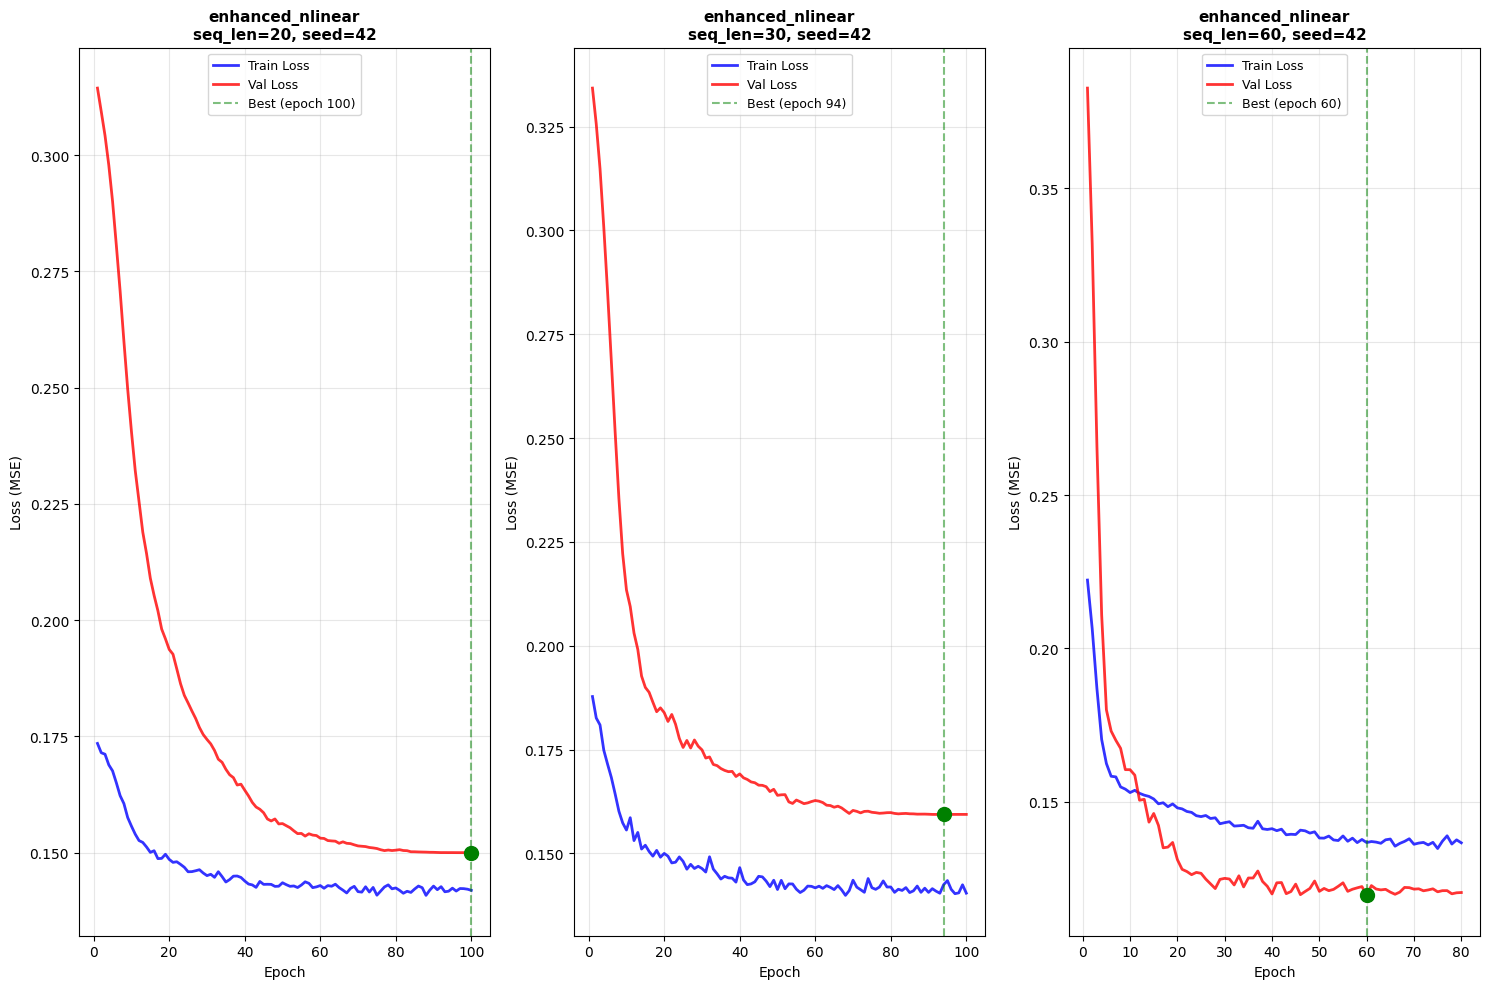

In [ ]:
# 1. Plot training history
trainer.plot_training_history(figsize=(15, 10))

### Ver1: Weighted Ensemble (No Dampening)

In [ ]:
predictions_weighted, all_preds = trainer.generate_weighted_ensemble_prediction(
    df, features,
    use_inverse_loss=True,
    top_k=None,
    return_individual=True
)
# Light smoothing only
predictions_v1 = pd.Series(predictions_weighted).rolling(3, center=True, min_periods=1).mean().values


GENERATING WEIGHTED ENSEMBLE PREDICTIONS

Model Weights (using inverse loss):
enhanced_nlinear     seq= 60 seed=  42 val_loss=0.119504 -> weight=0.3927
enhanced_nlinear     seq= 20 seed=  42 val_loss=0.149993 -> weight=0.3129
enhanced_nlinear     seq= 30 seed=  42 val_loss=0.159380 -> weight=0.2944

Last actual price: 120.11
First prediction: 122.32
Last prediction: 127.08
Total change: 5.80%



✓ Forecast plot saved as 'forecast_with_confidence.png'


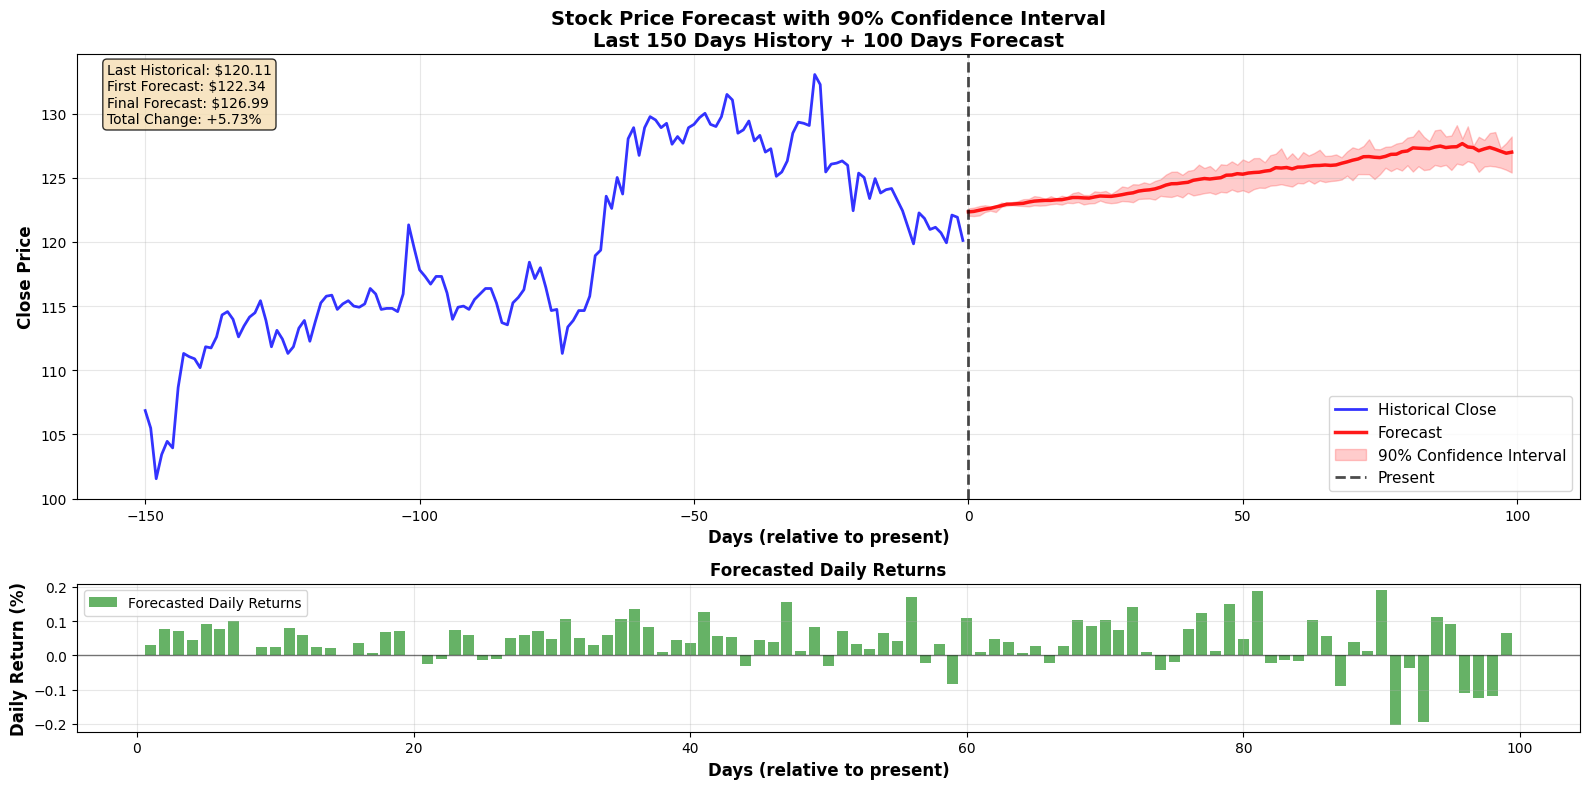


FORECAST SUMMARY STATISTICS
Historical Period: 150 days
Forecast Period: 100 days
Confidence Level: 90%

Price Statistics:
  Last Historical Price: $120.11
  First Forecast: $122.34 (+1.86%)
  Final Forecast: $126.99 (+5.73%)
  Forecast Mean: $125.14
  Forecast Std: $1.60
  Forecast Min: $122.34
  Forecast Max: $127.66

Confidence Interval:
  Final Lower Bound: $125.40
  Final Upper Bound: $128.21
  Interval Width: $2.81

Model Agreement:
  Std Dev of Final Predictions: $1.32
  Coefficient of Variation: 1.04%


In [ ]:
# Plot
trainer.plot_forecast_with_confidence(
    df=df,
    predictions=predictions_v1,
    all_predictions=all_preds,
    history_days=150,
    confidence_level=0.90,
    figsize=(16, 8)
)

In [ ]:
# Save
pd.DataFrame({'id': range(1, 101), 'close': predictions_v1}).to_csv('submission_v1.csv', index=False)

### Ver2: Weighted Ensemble + Gentle Dampening

In [ ]:
# Start with weighted ensemble
base_predictions = trainer.generate_weighted_ensemble_prediction(
    df, features,
    use_inverse_loss=True,
    return_individual=False
)

last_price = df['close'].iloc[-1]
recent_mean = df['close'].tail(30).mean()


GENERATING WEIGHTED ENSEMBLE PREDICTIONS

Model Weights (using inverse loss):
enhanced_nlinear     seq= 60 seed=  42 val_loss=0.119504 -> weight=0.3927
enhanced_nlinear     seq= 20 seed=  42 val_loss=0.149993 -> weight=0.3129
enhanced_nlinear     seq= 30 seed=  42 val_loss=0.159380 -> weight=0.2944

Last actual price: 120.11
First prediction: 122.32
Last prediction: 127.08
Total change: 5.80%


In [ ]:
predictions_v2 = []
for i in range(len(base_predictions)):
    decay_factor = 0.9975 ** (i + 1)

    dampened = decay_factor * base_predictions[i] + (1 - decay_factor) * recent_mean
    predictions_v2.append(dampened)

predictions_v2 = np.array(predictions_v2)

predictions_v2 = pd.Series(predictions_v2).rolling(3, center=True, min_periods=1).mean().values


✓ Forecast plot saved as 'forecast_with_confidence.png'


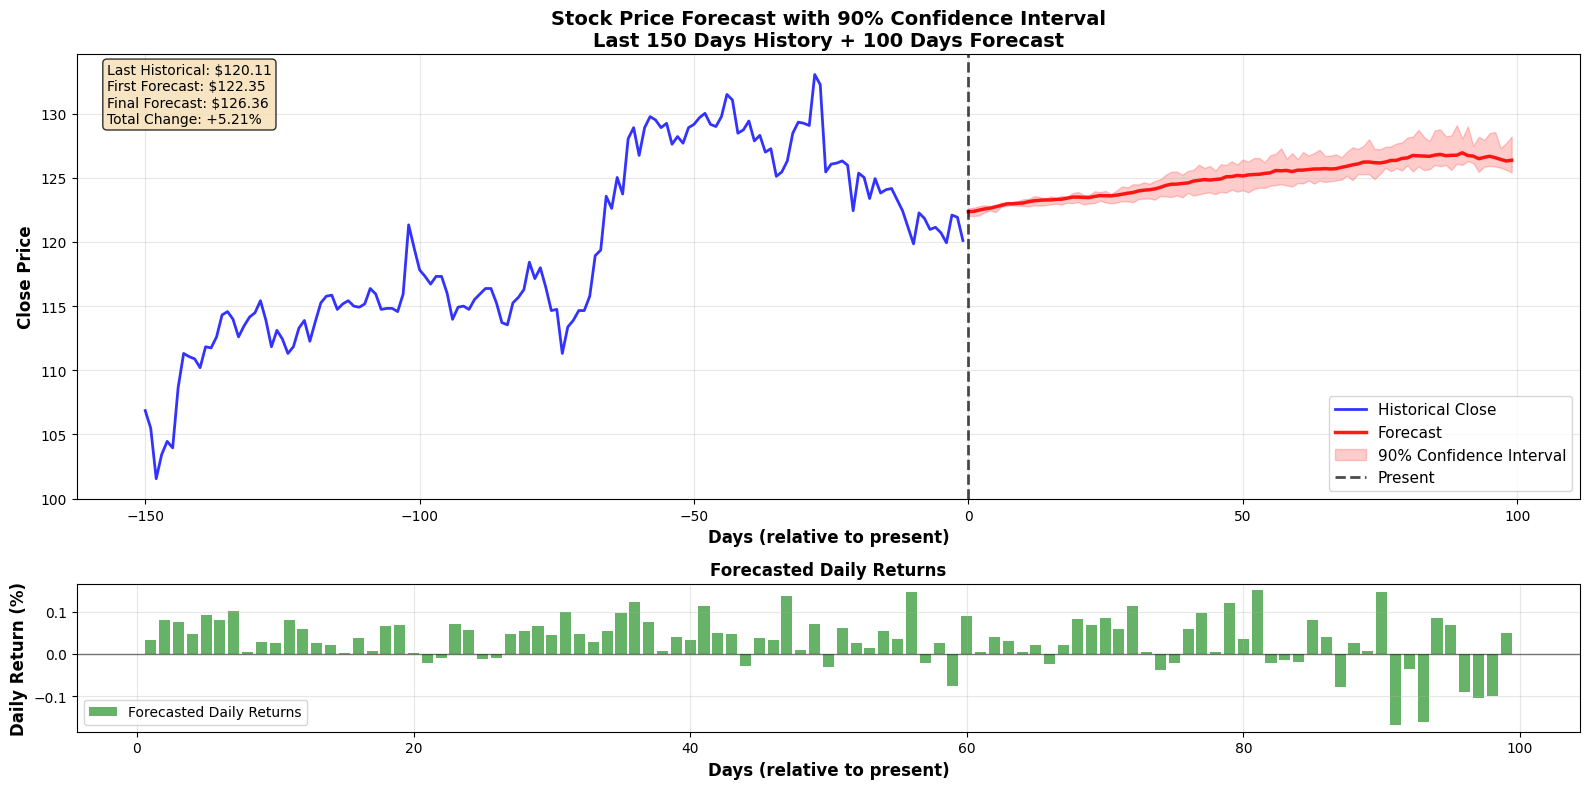


FORECAST SUMMARY STATISTICS
Historical Period: 150 days
Forecast Period: 100 days
Confidence Level: 90%

Price Statistics:
  Last Historical Price: $120.11
  First Forecast: $122.35 (+1.86%)
  Final Forecast: $126.36 (+5.21%)
  Forecast Mean: $124.93
  Forecast Std: $1.37
  Forecast Min: $122.35
  Forecast Max: $126.94

Confidence Interval:
  Final Lower Bound: $125.40
  Final Upper Bound: $128.21
  Interval Width: $2.81

Model Agreement:
  Std Dev of Final Predictions: $1.32
  Coefficient of Variation: 1.04%


In [ ]:
# Plot
trainer.plot_forecast_with_confidence(
    df=df,
    predictions=predictions_v2,
    all_predictions=all_preds,
    history_days=150,
    confidence_level=0.90,
    figsize=(16, 8)
)

In [ ]:
# Save
pd.DataFrame({'id': range(1, 101), 'close': predictions_v2}).to_csv('submission_v2.csv', index=False)

### Ver3: Trend-Aware Dampening

In [ ]:
# Get base predictions
base_predictions = trainer.generate_weighted_ensemble_prediction(
    df, features,
    use_inverse_loss=True,
    return_individual=False
)

last_price = df['close'].iloc[-1]

# Detect trend
recent_trend = df['close'].tail(50).values
trend_slope = np.polyfit(range(len(recent_trend)), recent_trend, 1)[0]
is_uptrend = trend_slope > 0

print(f"Detected trend: {'UPTREND' if is_uptrend else 'DOWNTREND'}")
print(f"Trend slope: {trend_slope:.4f}")


GENERATING WEIGHTED ENSEMBLE PREDICTIONS

Model Weights (using inverse loss):
enhanced_nlinear     seq= 60 seed=  42 val_loss=0.119504 -> weight=0.3927
enhanced_nlinear     seq= 20 seed=  42 val_loss=0.149993 -> weight=0.3129
enhanced_nlinear     seq= 30 seed=  42 val_loss=0.159380 -> weight=0.2944

Last actual price: 120.11
First prediction: 122.32
Last prediction: 127.08
Total change: 5.80%
Detected trend: DOWNTREND
Trend slope: -0.2101


In [ ]:
# Apply asymmetric dampening (less dampening in trend direction)
predictions_v3 = []
for i in range(len(base_predictions)):
    # Gentle dampening
    t = (i + 1) / len(base_predictions)  # Normalized time (0 to 1)

    if is_uptrend:
        # Allow upward predictions, dampen downward ones
        if base_predictions[i] >= last_price:
            dampening_strength = 0.1 * t  # Weak dampening upward
        else:
            dampening_strength = 0.3 * t  # Strong dampening downward
    else:
        # Allow downward predictions, dampen upward ones
        if base_predictions[i] <= last_price:
            dampening_strength = 0.1 * t  # Weak dampening downward
        else:
            dampening_strength = 0.3 * t  # Strong dampening upward

    # Linear interpolation between prediction and last price
    dampened = (1 - dampening_strength) * base_predictions[i] + dampening_strength * last_price
    predictions_v3.append(dampened)

predictions_v3 = np.array(predictions_v3)

# Very light smoothing
predictions_v3 = pd.Series(predictions_v3).rolling(3, center=True, min_periods=1).mean().values


✓ Forecast plot saved as 'forecast_with_confidence.png'


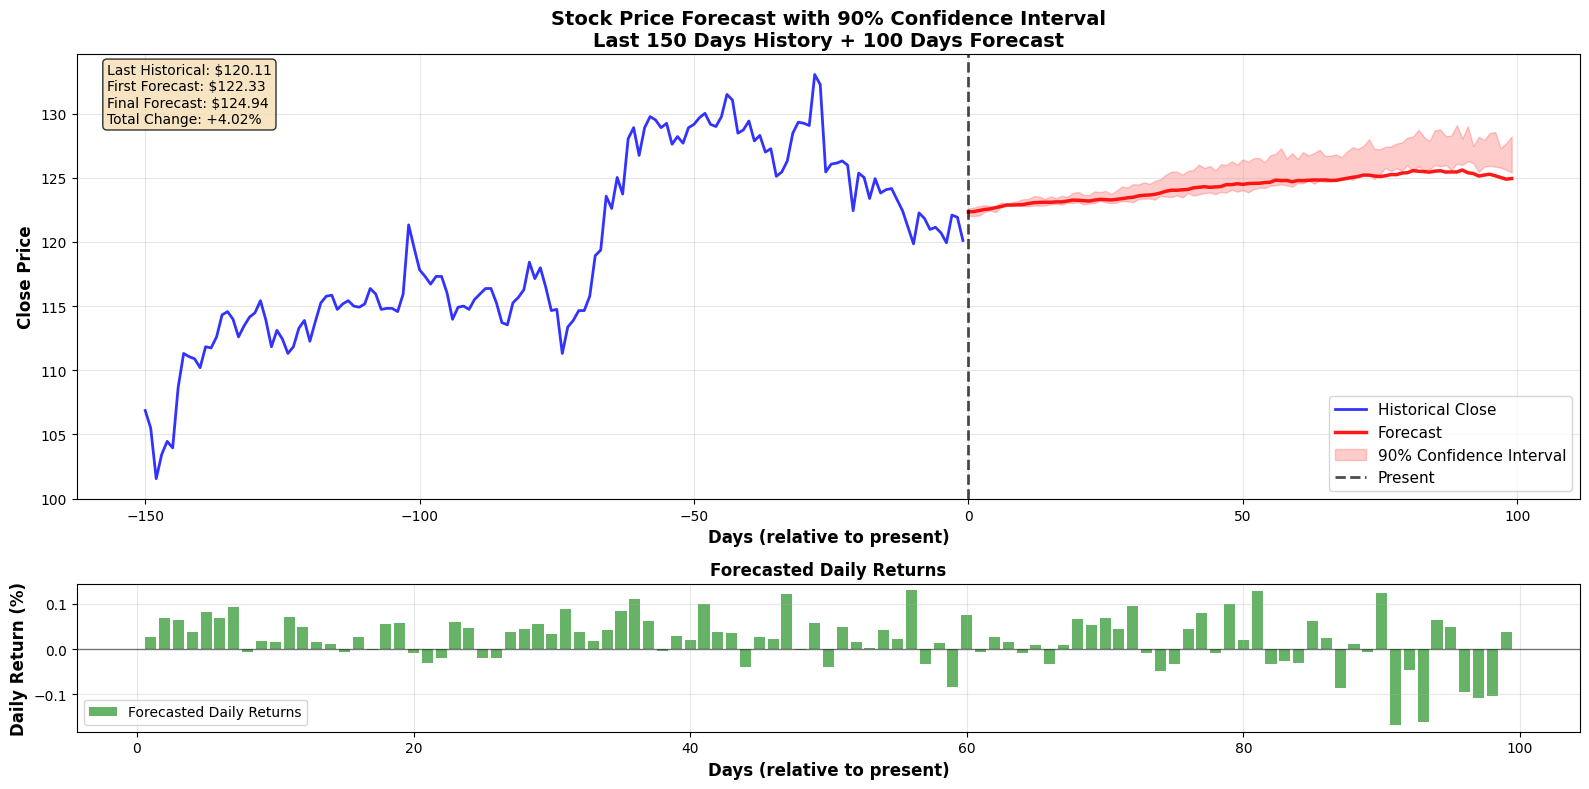


FORECAST SUMMARY STATISTICS
Historical Period: 150 days
Forecast Period: 100 days
Confidence Level: 90%

Price Statistics:
  Last Historical Price: $120.11
  First Forecast: $122.33 (+1.85%)
  Final Forecast: $124.94 (+4.02%)
  Forecast Mean: $124.24
  Forecast Std: $0.95
  Forecast Min: $122.33
  Forecast Max: $125.60

Confidence Interval:
  Final Lower Bound: $125.40
  Final Upper Bound: $128.21
  Interval Width: $2.81

Model Agreement:
  Std Dev of Final Predictions: $1.32
  Coefficient of Variation: 1.04%


In [ ]:
# Plot
trainer.plot_forecast_with_confidence(
    df=df,
    predictions=predictions_v3,
    all_predictions=all_preds,
    history_days=150,
    confidence_level=0.90,
    figsize=(16, 8)
)

In [ ]:
# Save
pd.DataFrame({'id': range(1, 101), 'close': predictions_v3}).to_csv('submission_v3.csv', index=False)

### Ver4: Weighted Ensemble + Quantile Clipping

In [ ]:
predictions_weighted, all_preds = trainer.generate_weighted_ensemble_prediction(
    df, features,
    use_inverse_loss=True,
    return_individual=True
)

# Calculate reasonable bounds from ensemble variance
lower_bound = np.percentile(all_preds, 10, axis=0)  # 10th percentile
upper_bound = np.percentile(all_preds, 90, axis=0)  # 90th percentile

# Also enforce maximum change constraint
last_price = df['close'].iloc[-1]
max_change_per_day = 0.02  # 2% per day maximum


GENERATING WEIGHTED ENSEMBLE PREDICTIONS

Model Weights (using inverse loss):
enhanced_nlinear     seq= 60 seed=  42 val_loss=0.119504 -> weight=0.3927
enhanced_nlinear     seq= 20 seed=  42 val_loss=0.149993 -> weight=0.3129
enhanced_nlinear     seq= 30 seed=  42 val_loss=0.159380 -> weight=0.2944

Last actual price: 120.11
First prediction: 122.32
Last prediction: 127.08
Total change: 5.80%


In [ ]:
predictions_v4 = [predictions_weighted[0]]
for i in range(1, len(predictions_weighted)):
    pred = predictions_weighted[i]

    # Clip by ensemble bounds
    pred = np.clip(pred, lower_bound[i], upper_bound[i])

    # Enforce max daily change from previous prediction
    max_allowed = predictions_v4[-1] * (1 + max_change_per_day)
    min_allowed = predictions_v4[-1] * (1 - max_change_per_day)
    pred = np.clip(pred, min_allowed, max_allowed)

    predictions_v4.append(pred)

predictions_v4 = np.array(predictions_v4)

# Light smoothing
predictions_v4 = pd.Series(predictions_v4).rolling(3, center=True, min_periods=1).mean().values


✓ Forecast plot saved as 'forecast_with_confidence.png'


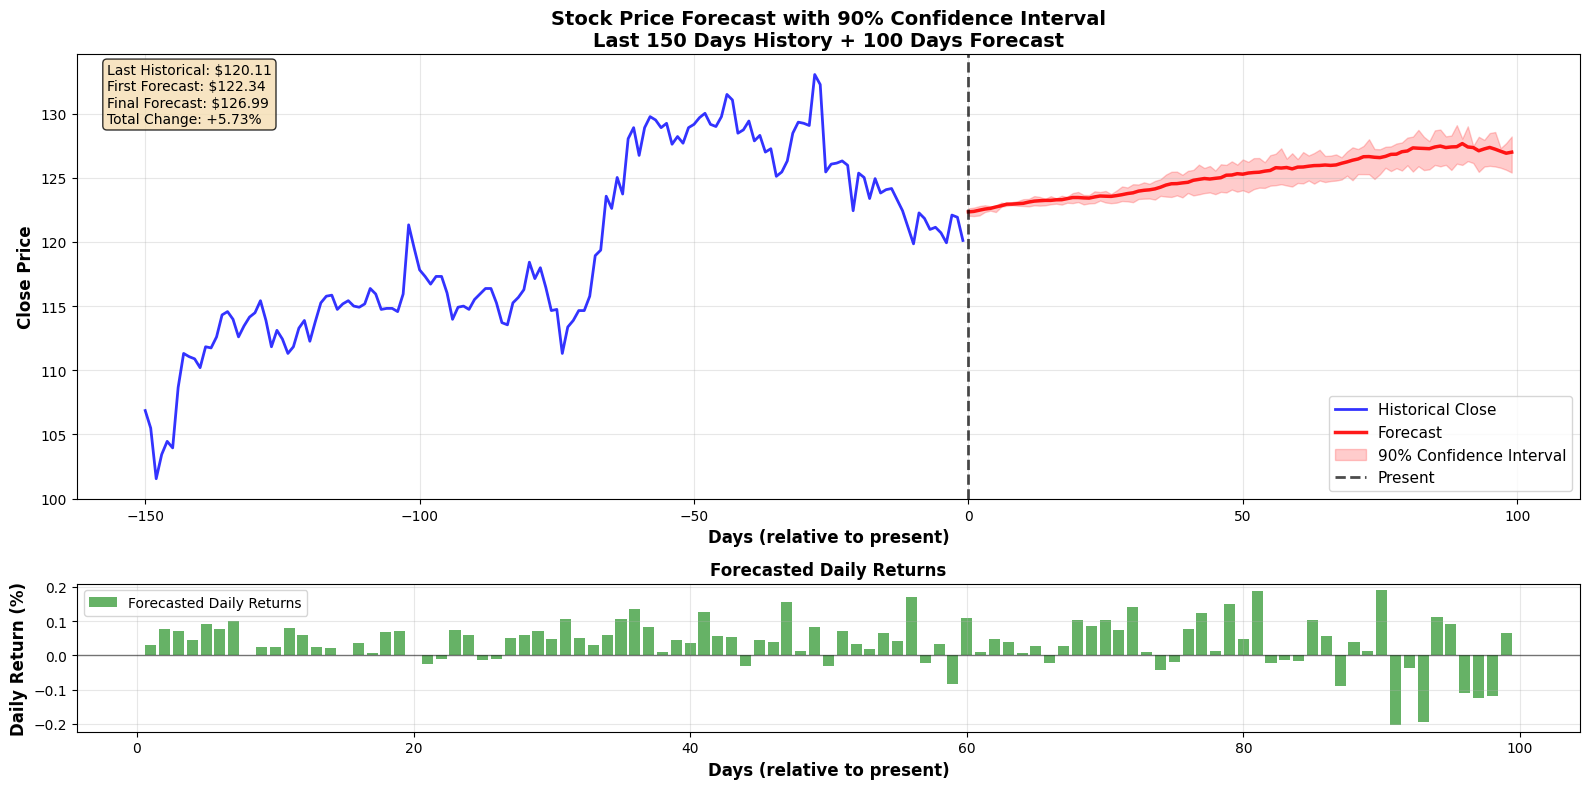


FORECAST SUMMARY STATISTICS
Historical Period: 150 days
Forecast Period: 100 days
Confidence Level: 90%

Price Statistics:
  Last Historical Price: $120.11
  First Forecast: $122.34 (+1.86%)
  Final Forecast: $126.99 (+5.73%)
  Forecast Mean: $125.14
  Forecast Std: $1.60
  Forecast Min: $122.34
  Forecast Max: $127.66

Confidence Interval:
  Final Lower Bound: $125.40
  Final Upper Bound: $128.21
  Interval Width: $2.81

Model Agreement:
  Std Dev of Final Predictions: $1.32
  Coefficient of Variation: 1.04%


In [ ]:
# Plot
trainer.plot_forecast_with_confidence(
    df=df,
    predictions=predictions_v4,
    all_predictions=all_preds,
    history_days=150,
    confidence_level=0.90,
    figsize=(16, 8)
)

In [ ]:
# Save
pd.DataFrame({'id': range(1, 101), 'close': predictions_v4}).to_csv('submission_v4.csv', index=False)

In [ ]:
print("\n" + "="*70)
print("PREDICTION COMPARISON SUMMARY")
print("="*70)

last_price = df['close'].iloc[-1]

print(f"\nLast actual price: ${last_price:.2f}")
print(f"\nFinal predictions (day 100):")
print(f"  V1 (Weighted only):           ${predictions_v1[-1]:.2f} ({((predictions_v1[-1]/last_price-1)*100):+.2f}%)")
print(f"  V2 (Gentle dampening):        ${predictions_v2[-1]:.2f} ({((predictions_v2[-1]/last_price-1)*100):+.2f}%)")
print(f"  V3 (Trend-aware):             ${predictions_v3[-1]:.2f} ({((predictions_v3[-1]/last_price-1)*100):+.2f}%)")
print(f"  V4 (Quantile clipping):       ${predictions_v4[-1]:.2f} ({((predictions_v4[-1]/last_price-1)*100):+.2f}%)")

print(f"\nMean predictions:")
print(f"  V1: ${predictions_v1.mean():.2f}")
print(f"  V2: ${predictions_v2.mean():.2f}")
print(f"  V3: ${predictions_v3.mean():.2f}")
print(f"  V4: ${predictions_v4.mean():.2f}")

print(f"\nStd deviation:")
print(f"  V1: ${predictions_v1.std():.2f}")
print(f"  V2: ${predictions_v2.std():.2f}")
print(f"  V3: ${predictions_v3.std():.2f}")
print(f"  V4: ${predictions_v4.std():.2f}")

print("\n" + "="*70)
print("RECOMMENDATION:")
print("  1. Try V1 first (simplest, trust the model)")
print("  2. If V1 looks too extreme, try V4 (clipped)")
print("  3. If trending stock, try V3 (trend-aware)")
print("  4. Avoid V2 unless you need very conservative predictions")
print("="*70)


PREDICTION COMPARISON SUMMARY

Last actual price: $120.11

Final predictions (day 100):
  V1 (Weighted only):           $126.99 (+5.73%)
  V2 (Gentle dampening):        $126.36 (+5.21%)
  V3 (Trend-aware):             $124.94 (+4.02%)
  V4 (Quantile clipping):       $126.99 (+5.73%)

Mean predictions:
  V1: $125.14
  V2: $124.93
  V3: $124.24
  V4: $125.14

Std deviation:
  V1: $1.60
  V2: $1.37
  V3: $0.95
  V4: $1.60

RECOMMENDATION:
  1. Try V1 first (simplest, trust the model)
  2. If V1 looks too extreme, try V4 (clipped)
  3. If trending stock, try V3 (trend-aware)
  4. Avoid V2 unless you need very conservative predictions
